# The Jupyter Notebook that Analyses R  
**Damian**

---

This notebook is structured as follows:

In the first cell below, an overview is given of the research into the observational biases that affect luminosity ($L$) and effective temperature ($T_{\mathrm{eff}}$), and therefore also influence the derived stellar radius ($R$) and all associated ratios. In the same cell, following the explanation of these biases and their effects, methods for correcting these biases are discussed.

In the next cell (not yet created), all required imports will be included.

In the cell after that (also not yet created), the necessary data will be loaded.

Finally, in the following cell (also not yet created), the data analysis and bias correction will be performed.

# Information about the biases affecting R.

This section summarizes the main observational biases affecting binary star systems, and how these biases influence the measured luminosity ($L$), effective temperature ($T_{\mathrm{eff}}$), and derived stellar radius ($R$), as well as their ratios.

---

## 1. Luminosity (Brightness) Bias

**Explanation**  
Brighter systems are easier to detect than faint systems, especially at larger distances. As a result, intrinsically luminous stars and systems are overrepresented in the dataset, while faint systems fall below the detection threshold.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
This bias leads to an overestimation of the average luminosity $L$. Since hotter stars are generally more luminous, the average effective temperature $T_{\mathrm{eff}}$ is also biased toward higher values. Because the stellar radius depends on both parameters,
$$
R \propto \frac{\sqrt{L}}{T_{\mathrm{eff}}^2},
$$
an increase in $L$ leads to larger inferred radii, while an increase in $T_{\mathrm{eff}}$ partially counteracts this effect.

**Effect on Ratios**  
Systems with large luminosity differences are harder to detect, so luminosity ratios tend to be biased toward values closer to 1. Extreme ratios are underrepresented.

---

## 2. Temperature Bias

**Explanation**  
Hotter stars are brighter and have clearer spectral features, making them easier to detect and analyze. Cooler stars are fainter and can be more difficult to identify, especially in binary systems.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
This bias results in an overrepresentation of stars with high $T_{\mathrm{eff}}$. Since temperature and luminosity are correlated, $L$ is also biased toward higher values. Because $R \propto T^{-2}$, an overestimated temperature can lead to underestimated stellar radii.

**Effect on Ratios**  
Cooler secondary stars are more likely to be missed or poorly measured, causing temperature ratios to cluster closer to 1 and reducing the number of systems with large temperature contrasts.

---

## 3. Mass-Ratio Bias

**Explanation**  
Binary systems with similar components (mass ratio $q \approx 1$) are easier to detect than systems where one star is much fainter than the other. In high-contrast systems, the secondary component may be lost in the light of the primary.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
Because similar-component systems are overrepresented, the measured values of $L$ and $T_{\mathrm{eff}}$ for the two stars tend to be more alike. This also leads to less variation in the derived stellar radii.

**Effect on Ratios**  
Ratios such as $L_1/L_2$, $T_1/T_2$, and $R_1/R_2$ are biased toward unity, while extreme values are underrepresented.

---

## 4. Inclination Bias

**Explanation**  
The detection of certain binary systems depends on their orbital inclination. For example, eclipsing binaries are only observable when the system is viewed nearly edge-on.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
This bias selects systems that are easier to characterize, leading to more reliable measurements of $L$, $T_{\mathrm{eff}}$, and $R$. However, these systems are not necessarily representative of the full binary population.

**Effect on Ratios**  
Ratios in these systems are often more accurately determined, but the sample is biased toward systems that are favorable for observation, which may indirectly affect the observed distribution.

---

## 5. Period Bias

**Explanation**  
Short-period binaries are easier to detect because they show more frequent eclipses and larger radial velocity variations. Long-period systems are less likely to be identified as binaries.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
Short-period systems often experience interactions such as tidal locking or mass transfer, which can make the component stars more similar in temperature and luminosity. This can influence the measured distributions of $L$ and $T_{\mathrm{eff}}$.

**Effect on Ratios**  
Because the components tend to be more similar, the ratios $L_1/L_2$, $T_1/T_2$, and $R_1/R_2$ are more likely to be close to 1.

---

## 6. Blending / Unresolved Bias

**Explanation**  
In some cases, two stars cannot be resolved individually and appear as a single object. This is especially common when one component is much fainter than the other.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
The measured flux is then a combination of both stars, leading to an overestimation of $L$ and a distorted estimate of $T_{\mathrm{eff}}$. This propagates into errors in the derived stellar radius $R$.

**Effect on Ratios**  
Systems with large differences between components may be misidentified as single stars and therefore excluded from the dataset. As a result, extreme ratios are underrepresented, and observed ratios are biased toward values near 1.



# Information regarding populations
**Explanation**
Binary systems are not too easy to observe, we cant visually separate 2 stars when they are millions of lightyears away, so binary system observations are limited to our local universe.

We can categorize the binary systems in pairs of certain stars. We create a couple groups:
Main sequence stars
White dwarfs
Brown dwarfs
Giants
Other (this includes super giants, neutron stars, etc..)

**Why do we need to know this?**
If we assume for a moment that each type of star has the same probability of forming a binary system with another star, then we have 15 different possibilities of forming a binary system.
Because of our assumption that all stars are equally likely of forming a binary system, the chance of finding a binary system that is a combination of any 2 stars in this system, is proportional to the probability of any star being a certain star.
So we need to determine how often certain types of stars occur in our lokal universe. Some theoretical papers about that are noted below:
https://arxiv.org/abs/astro-ph/0009005
https://arxiv.org/abs/astro-ph/0304382
https://arxiv.org/abs/1001.2965
https://arxiv.org/abs/astro-ph/0502524

this provides the following distribution:

Main sequence: 91.5%
White dwarfs: 5.5%
Brown dwarfs: 2.0%
Giants: 0.7%
Other: 0.3%

In [54]:
# Imports here:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.stats import gaussian_kde


In [55]:
# Inlezen en eerste processing van data zodat analyse mogelijk is





# ============================================================
# 1. Data inlezen
# ============================================================

df = pd.read_csv(r'DATA/RAW/L_SP.csv')
df_L = None
df_sp = None

print("Totaal aantal rows:", len(df))





# ============================================================
# 2. Overzicht van databases/catalogi
# ============================================================

print("\n===== DATABASE OVERZICHT =====")

catalogue_counts = (
    df["catalogue"]
    .value_counts()
    .reset_index()
)

catalogue_counts.columns = ["catalogue", "n_rows"]

print(catalogue_counts)





# ============================================================
# 3. system_id en component uit bsdb halen
# ============================================================

# voorbeeld:
# J000026.44+242931.2:c1
#
# -> system_id = J000026.44+242931.2
# -> component = c1

df[["system_id", "component"]] = (
    df["bsdb"]
    .str.split(":", expand=True)
)

# ============================================================
# Overzicht van component-combinaties per systeem
# ============================================================

# unieke componenten per systeem verzamelen
system_components = (
    df.groupby("system_id")["component"]
    .unique()
)

# componenten sorteren zodat:
# [c2, c1] en [c1, c2]
# als dezelfde combinatie tellen
component_patterns = (
    system_components
    .apply(lambda x: tuple(sorted(x)))
)

# tellen hoe vaak elke combinatie voorkomt
pattern_counts = (
    component_patterns
    .value_counts()
    .reset_index()
)

pattern_counts.columns = [
    "component_combination",
    "n_systems"
]

# ============================================================
# Resultaten printen
# ============================================================

print("\n===== COMPONENT COMBINATIES =====\n")

for _, row in pattern_counts.iterrows():

    combination = row["component_combination"]
    count = row["n_systems"]

    print(f"{combination} -> {count}")

# ============================================================
# Pair entries verwijderen
# ============================================================

# pair/orbit entries beginnen met "p"
# deze zijn geen echte sterren

df = df[
    ~df["component"].str.startswith("p", na=False)
]

print("\nRows na verwijderen van pair entries:", len(df))

# ============================================================
# Alleen systemen met exact 2 componenten behouden
# ============================================================

# aantal unieke componenten per systeem bepalen
n_components_per_system = (
    df.groupby("system_id")["component"]
    .nunique()
)

# systemen met exact 2 componenten selecteren
binary_systems = n_components_per_system[
    n_components_per_system == 2
].index

# dataframe filteren
df = df[
    df["system_id"].isin(binary_systems)
]

print("Aantal systemen met exact 2 componenten:",
      len(binary_systems))

print("Aantal rows in binary dataframe:", len(df))

# ============================================================
# Controle van overgebleven component-combinaties
# ============================================================

binary_components = (
    df.groupby("system_id")["component"]
    .unique()
    .apply(lambda x: tuple(sorted(x)))
)

binary_pattern_counts = (
    binary_components
    .value_counts()
    .reset_index()
)

binary_pattern_counts.columns = [
    "component_combination",
    "n_systems"
]

print("\n===== OVERGEBLEVEN BINARY COMBINATIES =====\n")

for _, row in binary_pattern_counts.iterrows():

    combination = row["component_combination"]
    count = row["n_systems"]

    print(f"{combination} -> {count}")





# ============================================================
# 4. Alleen rows behouden met bekende luminositeit (L)
# ============================================================

df_L = df.copy()

df_L["L"] = df_L["L"].replace("", pd.NA)
df_L = df_L.dropna(subset=["L"])

df_L["L"] = pd.to_numeric(df_L["L"], errors="coerce")
df_L = df_L.dropna(subset=["L"])

print("Rows met bekende L:", len(df_L))





# ============================================================
# 5. Controle van beschikbare luminosity catalogi
# ============================================================

print("\n===== LUMINOSITY CATALOGI =====")

luminosity_catalogues = (
    df_L["catalogue"]
    .value_counts()
)

print("df_L rows:", len(df_L))

print("\n===== LUMINOSITY CATALOGI =====")

luminosity_catalogues = (
    df_L["catalogue"]
    .value_counts()
    .rename_axis("catalogue")
    .reset_index(name="n_rows")
)

print(luminosity_catalogues.to_string(index=False))





# ============================================================
# 6. MNRAS luminosities omzetten
# ============================================================

# J/MNRAS/491/5489 gebruikt:
# log10(L/Lsun)
#
# omzetting:
# L/Lsun = 10^(logL)

mask_mnras = (
    df_L["catalogue"] == "J/MNRAS/491/5489"
)

df_L.loc[mask_mnras, "L"] = (
    10 ** df_L.loc[mask_mnras, "L"]
)

print(
    "\nMNRAS luminosities omgezet van "
    "log(L/Lsun) naar L/Lsun"
)





# ============================================================
# 7. Alleen rows behouden met bekende spectraalklasse
# ============================================================

df_sp = df.copy()

# lege strings / whitespace → NaN
df_sp["spType"] = df_sp["spType"].replace("", pd.NA)
df_sp["spType"] = df_sp["spType"].astype(str).str.strip()

# eventueel "nan" strings opruimen (komen vaak voor na copy/CSV load)
invalid_values = ["nan", "NaN", "null", "---", "..."]
df_sp.loc[df_sp["spType"].isin(invalid_values), "spType"] = pd.NA

# alleen rows met geldige spectraalklasse behouden
df_sp = df_sp.dropna(subset=["spType"])

print("Rows met bekende spectraalklasse:", len(df_sp))





# ============================================================
# 8. Dimensieloze luminosity fusie per ster voor alle dimensieloze catalogi
# ============================================================

dimless_catalogues = ["V/118", "Svechnikov84", "Svechnikov99"]

df_dim = df_L[df_L["catalogue"].isin(dimless_catalogues)].copy()

# ============================================================
# 8.1 Unieke sterren (system, component)
# ============================================================

stars_dim = (
    df_dim[["system_id", "component"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# ============================================================
# 8.2. Systems scheiden in:
#    - lijst_1: slechts 1 component in df_dim
#    - lijst_2: 2+ components in df_dim
# ============================================================

counts = (
    df_dim.groupby("system_id")["component"]
    .nunique()
)

list_1_systems = counts[counts == 1].index
list_2_systems = counts[counts >= 2].index

list_1 = stars_dim[stars_dim["system_id"].isin(list_1_systems)]
list_2 = stars_dim[stars_dim["system_id"].isin(list_2_systems)]

print("Single-component systems:", len(list_1))
print("Multi-component systems:", len(list_2))

# ============================================================
# 8.3. Lijst 1 verwerking
# ============================================================

new_rows = []

for _, row in list_1.iterrows():

    sys = row["system_id"]
    comp = row["component"]

    subset = df_dim[
        (df_dim["system_id"] == sys) &
        (df_dim["component"] == comp)
    ]

    # ------------------------------------------------------------
    # 8.3.1 per catalogue mean + sigma
    # ------------------------------------------------------------

    cat_stats = []

    for cat, group in subset.groupby("catalogue"):

        values = group["L"].values
        mean_L = values.mean()

        if len(values) == 1:
            std_L = 0.05 * mean_L
        else:
            std_L = values.std()

        cat_stats.append((cat, mean_L, std_L, len(values)))

    # ------------------------------------------------------------
    # 8.3.2 weighted average over catalogues
    # ------------------------------------------------------------

    weights = []
    means = []

    for cat, mean_L, std_L, n in cat_stats:

        sigma_safe = max(std_L, 0.05 * mean_L)
        w = 1 / (sigma_safe ** 2)

        weights.append(w)
        means.append(mean_L)

    weights = np.array(weights)
    means = np.array(means)

    L_final = np.sum(weights * means) / np.sum(weights)
    sigma_final = np.sqrt(1 / np.sum(weights))

    # meest voorkomende catalogue als label
    best_cat = subset["catalogue"].value_counts().idxmax()

    # ------------------------------------------------------------
    # 8.3.3 oude entries verwijderen + nieuwe toevoegen
    # ------------------------------------------------------------

    df_L = df_L[~(
        (df_L["system_id"] == sys) &
        (df_L["component"] == comp) &
        (df_L["catalogue"].isin(dimless_catalogues))
    )]

    new_rows.append({
        "system_id": sys,
        "component": comp,
        "L": L_final,
        "L_err": sigma_final,
        "catalogue": best_cat
    })

# ============================================================
# 8.4 Nieuwe rows toevoegen
# ============================================================

df_L = pd.concat([df_L, pd.DataFrame(new_rows)], ignore_index=True)

# ============================================================
# 8.5 Lijst 2 verwerking (beide componenten aanwezig in dimensieloze catalogi)
# ============================================================

new_rows_2 = []

for sys in list_2_systems:

    # ------------------------------------------------------------
    # haal alle componenten van dit systeem in df_dim
    # ------------------------------------------------------------

    system_data = df_dim[df_dim["system_id"] == sys]

    components = system_data["component"].unique()

    if len(components) < 2:
        continue  # veiligheid

    comp_results = {}

    # ============================================================
    # 8.5.1 + 8.5.2: per component catalogue stats
    # ============================================================

    for comp in components:

        subset = system_data[system_data["component"] == comp]

        cat_stats = []

        for cat, group in subset.groupby("catalogue"):

            values = group["L"].values
            mean_L = values.mean()

            if len(values) == 1:
                std_L = 0.05 * mean_L
            else:
                std_L = values.std()

            sigma_safe = max(std_L, 0.05 * mean_L)

            cat_stats.append((cat, mean_L, sigma_safe, len(values)))

        # ========================================================
        # 8.5.3 weighted average per component
        # ========================================================

        weights = np.array([1 / (s**2) for _, _, s, _ in cat_stats])
        means = np.array([m for _, m, _, _ in cat_stats])

        L_comp = np.sum(weights * means) / np.sum(weights)
        sigma_comp = np.sqrt(1 / np.sum(weights))

        comp_results[comp] = (L_comp, sigma_comp, cat_stats)

    # ============================================================
    # 8.5.4 keuze beste component (laagste sigma)
    # ============================================================

    comp_list = list(comp_results.keys())

    if len(comp_list) != 2:
        continue  # we verwachten binaries

    c1, c2 = comp_list

    L1, s1, stats1 = comp_results[c1]
    L2, s2, stats2 = comp_results[c2]

    if s1 <= s2:
        best_L = L1
        best_sigma = s1
        best_comp = c1
        other_comp = c2
    else:
        best_L = L2
        best_sigma = s2
        best_comp = c2
        other_comp = c1

    # ============================================================
    # 8.5.5 reconstructie companion
    # ============================================================

    L_best = best_L
    L_other = 1 - best_L
    sigma_other = best_sigma

    best_cat = system_data["catalogue"].value_counts().idxmax()

    # ------------------------------------------------------------
    # oude dimensieloze entries verwijderen
    # ------------------------------------------------------------

    df_L = df_L[~(
        (df_L["system_id"] == sys) &
        (df_L["catalogue"].isin(dimless_catalogues))
    )]

    # ------------------------------------------------------------
    # nieuwe entries toevoegen
    # ------------------------------------------------------------

    new_rows_2.append({
        "system_id": sys,
        "component": best_comp,
        "L": best_L,
        "L_err": best_sigma,
        "catalogue": best_cat
    })

    new_rows_2.append({
        "system_id": sys,
        "component": other_comp,
        "L": L_other,
        "L_err": sigma_other,
        "catalogue": best_cat
    })

# ============================================================
# 8.5.6 commit naar df_L
# ============================================================

df_L = pd.concat([df_L, pd.DataFrame(new_rows_2)], ignore_index=True)





# ============================================================
# 9: V/118 database uitbreiden naar de volledige dataframe (missende sterren toevoegen)
# ============================================================

df_v118 = df_L[df_L["catalogue"] == "V/118"].copy()
df_raw = df.copy()

print("V/118 rows:", len(df_v118))

new_rows = []

# ============================================================
# 9.1: loop over alle V/118 entries
# ============================================================

for _, row in df_v118.iterrows():

    system = row["system_id"]
    L_primary = row["L"]
    L_err_primary = row.get("L_err", np.nan)
    catalogue = row["catalogue"]

    # ========================================================
    # 9.2: check of companion AL IN df_L zit (alle catalogi)
    # ========================================================

    comps_in_L = set(
        df_L[df_L["system_id"] == system]["component"]
    )

    if len(comps_in_L) >= 2:
        continue

    # ========================================================
    # 9.3: haal echte system-structuur uit raw df
    # ========================================================

    comps_in_raw = set(
        df_raw[df_raw["system_id"] == system]["component"]
    )

    missing_comps = comps_in_raw - comps_in_L

    # ========================================================
    # 9.4: voeg missing component toe aan df_L
    # ========================================================

    for comp in missing_comps:

        new_rows.append({
            "system_id": system,
            "component": comp,
            "catalogue": catalogue,
            "L": 1 - L_primary,
            "L_err": L_err_primary
        })

# ============================================================
# 9.5: direct toevoegen aan df_L
# ============================================================

if len(new_rows) > 0:
    df_L = pd.concat([df_L, pd.DataFrame(new_rows)], ignore_index=True)

print("Nieuwe entries toegevoegd:", len(new_rows))
print("Nieuwe df_L size:", len(df_L))





# ============================================================
# 10: dataframe met dimensieloze Svechnikov catalogi uitbreiden
# ============================================================

dimensionless_catalogues = [
    "Svechnikov84",
    "Svechnikov99"
]

df_svechnikov_L = df_L[
    df_L["catalogue"].isin(dimensionless_catalogues)
].copy()

print("Svechnikov rows:", len(df_svechnikov_L))

new_rows = []

for _, row in df_svechnikov_L.iterrows():

    system = row["system_id"]
    L1 = row["L"]
    L1_err = row.get("L_err", np.nan)
    catalogue = row["catalogue"]

    # ========================================================
    # 10.1: check of systeem al compleet is in df_L
    # ========================================================

    comps_in_L = set(
        df_L[df_L["system_id"] == system]["component"]
    )

    if len(comps_in_L) >= 2:
        continue

    # ========================================================
    # 10.2: companion zoeken in originele raw dataframe
    # ========================================================

    comps_in_raw = set(
        df_raw[df_raw["system_id"] == system]["component"]
    )

    missing_comps = comps_in_raw - comps_in_L

    # ========================================================
    # 10.3: companion toevoegen met L2 = 1 - L1
    # ========================================================

    for comp in missing_comps:

        new_rows.append({
            "system_id": system,
            "component": comp,
            "catalogue": catalogue,
            "L": 1 - L1,
            "L_err": L1_err
        })

# ============================================================
# toevoegen aan df_L
# ============================================================

if len(new_rows) > 0:

    df_L = pd.concat(
        [df_L, pd.DataFrame(new_rows)],
        ignore_index=True
    )

print("Nieuwe companion rows toegevoegd:", len(new_rows))
print("Nieuwe grootte df_L:", len(df_L))





# ============================================================
# 11. Alleen systemen behouden waarvoor L-ratio bepaalbaar is
# ============================================================

# een systeem is bruikbaar als:
# - beide componenten een bekende L hebben
#
# systemen met slechts 1 component in df_L verwijderen we,
# want daarvan kunnen we geen luminosity-ratio bepalen

# aantal unieke componenten per systeem in df_L
n_L_components = (
    df_L.groupby("system_id")["component"]
    .nunique()
)

# systemen met beide componenten aanwezig
valid_L_systems = n_L_components[
    n_L_components == 2
].index

# df_L filteren
df_L = df_L[
    df_L["system_id"].isin(valid_L_systems)
]

# ============================================================
# Controle
# ============================================================

print("\n===== FILTER OP COMPLETE L-SYSTEMEN =====")

print(
    "Aantal systemen met complete luminosity informatie:",
    len(valid_L_systems)
)

print(
    "Aantal rows in df_L:",
    len(df_L)
)

# ============================================================
# Extra controle:
# kijken of elk systeem nu exact 2 componenten heeft
# ============================================================

check_counts = (
    df_L.groupby("system_id")["component"]
    .nunique()
)

print("\nUnieke aantallen componenten in df_L:")

print(check_counts.value_counts().sort_index())





# ============================================================
# 12. Absolute luminosity fusie (II/150A + MNRAS)
# ============================================================

abs_catalogues = ["II/150A", "J/MNRAS/491/5489"]

df_abs = df_L[df_L["catalogue"].isin(abs_catalogues)].copy()

# ============================================================
# 12.1 Unieke sterren met absolute L
# ============================================================

stars_abs = (
    df_abs[["system_id", "component"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# ============================================================
# 12.2 verwerking per ster
# ============================================================

new_rows_abs = []

for _, row in stars_abs.iterrows():

    sys = row["system_id"]
    comp = row["component"]

    subset = df_abs[
        (df_abs["system_id"] == sys) &
        (df_abs["component"] == comp)
    ]

    cat_stats = []

    for cat, group in subset.groupby("catalogue"):

        values = group["L"].values
        mean_L = values.mean()

        if len(values) == 1:
            std_L = 0.05 * mean_L
        else:
            std_L = values.std()

        sigma_safe = max(std_L, 0.05 * mean_L)

        cat_stats.append((cat, mean_L, sigma_safe, len(values)))

    # ------------------------------------------------------------
    # 12.3 weighted average over catalogues
    # ------------------------------------------------------------

    weights = np.array([1 / (s**2) for _, _, s, _ in cat_stats])
    means = np.array([m for _, m, _, _ in cat_stats])

    L_final = np.sum(weights * means) / np.sum(weights)
    sigma_final = np.sqrt(1 / np.sum(weights))

    # meest voorkomende catalogue als label
    best_cat = subset["catalogue"].value_counts().idxmax()

    # ============================================================
    # 12.4 oude entries verwijderen + nieuwe toevoegen
    # ============================================================

    df_L = df_L[~(
        (df_L["system_id"] == sys) &
        (df_L["component"] == comp) &
        (df_L["catalogue"].isin(abs_catalogues))
    )]

    new_rows_abs.append({
        "system_id": sys,
        "component": comp,
        "L": L_final,
        "L_err": sigma_final,
        "catalogue": best_cat
    })

# ============================================================
# 12.5 commit naar df_L
# ============================================================

df_L = pd.concat([df_L, pd.DataFrame(new_rows_abs)], ignore_index=True)
print("")
print("Nieuwe grootte df_L na abs catalogues samenvoegen:", len(df_L))
print("")




# ============================================================
# 13. Dimensieloze L omzetten naar absolute L/Lsun
# ============================================================

absolute_catalogues = [
    "II/150A",
    "J/MNRAS/491/5489"
]

dimensionless_catalogues = [
    "V/118",
    "Svechnikov84",
    "Svechnikov99"
]

# ============================================================
# 13.1 sterren met EXACT 1 totale L-entry
# ============================================================

star_counts = (
    df_L.groupby(["system_id", "component"])
    .size()
    .reset_index(name="n_entries")
)

single_entry_stars = star_counts[
    star_counts["n_entries"] == 1
][["system_id", "component"]]

print("Sterren met exact 1 L-entry:", len(single_entry_stars))

# ============================================================
# 13.2 single-entry sterren splitsen:
#      absolute vs dimensieloos
# ============================================================

single_abs = df_L.merge(
    single_entry_stars,
    on=["system_id", "component"]
)

single_abs = single_abs[
    single_abs["catalogue"].isin(absolute_catalogues)
][["system_id", "component", "catalogue"]]

single_dim = df_L.merge(
    single_entry_stars,
    on=["system_id", "component"]
)

single_dim = single_dim[
    single_dim["catalogue"].isin(dimensionless_catalogues)
][["system_id", "component", "catalogue"]]

print("Single-entry absolute sterren:", len(single_abs))
print("Single-entry dimensieloze sterren:", len(single_dim))

# ============================================================
# 13.3 systemen zoeken:
#      absolute ster + dimensieloze companion
# ============================================================

conversion_systems = []

for _, abs_row in single_abs.iterrows():

    system = abs_row["system_id"]
    abs_comp = abs_row["component"]

    # alle dimensieloze sterren in dit systeem
    dim_matches = single_dim[
        single_dim["system_id"] == system
    ]

    # exact 1 companion nodig
    if len(dim_matches) != 1:
        continue

    dim_comp = dim_matches.iloc[0]["component"]

    # niet dezelfde component
    if dim_comp == abs_comp:

        continue

    conversion_systems.append({
        "system_id": system,
        "abs_comp": abs_comp,
        "dim_comp": dim_comp
    })

conversion_df = pd.DataFrame(conversion_systems)

print("Conversie-systemen:", len(conversion_df))

# ============================================================
# 13.4 dimensieloze L -> absolute L berekenen
# ============================================================

new_rows = []

for _, row in conversion_df.iterrows():

    system = row["system_id"]

    abs_comp = row["abs_comp"]
    dim_comp = row["dim_comp"]

    # --------------------------------------------------------
    # absolute component ophalen
    # --------------------------------------------------------

    abs_row = df_L[
        (df_L["system_id"] == system) &
        (df_L["component"] == abs_comp) &
        (df_L["catalogue"].isin(absolute_catalogues))
    ].iloc[0]

    L_abs = abs_row["L"]
    sigma_abs = abs_row.get("L_err", 0.05 * L_abs)

    abs_catalogue = abs_row["catalogue"]

    # --------------------------------------------------------
    # dimensieloze component ophalen
    # --------------------------------------------------------

    dim_row = df_L[
        (df_L["system_id"] == system) &
        (df_L["component"] == dim_comp) &
        (df_L["catalogue"].isin(dimensionless_catalogues))
    ].iloc[0]

    f = dim_row["L"]
    sigma_f = dim_row.get("L_err", 0.05 * f)

    # --------------------------------------------------------
    # absolute luminositeit berekenen
    # --------------------------------------------------------

    L_dim_abs = (f / (1 - f)) * L_abs

    # --------------------------------------------------------
    # foutpropagatie
    # --------------------------------------------------------

    sigma_dim_abs = np.sqrt(
        (
            (L_abs / (1 - f)**2) * sigma_f
        )**2
        +
        (
            (f / (1 - f)) * sigma_abs
        )**2
    )

    # --------------------------------------------------------
    # oude dimensieloze row verwijderen
    # --------------------------------------------------------

    df_L = df_L[~(
        (df_L["system_id"] == system) &
        (df_L["component"] == dim_comp) &
        (df_L["catalogue"].isin(dimensionless_catalogues))
    )]

    # --------------------------------------------------------
    # nieuwe absolute row toevoegen
    # --------------------------------------------------------

    new_rows.append({
        "system_id": system,
        "component": dim_comp,
        "L": L_dim_abs,
        "L_err": sigma_dim_abs,
        "catalogue": abs_catalogue
    })

# ============================================================
# 13.5 nieuwe rows toevoegen aan df_L
# ============================================================

if len(new_rows) > 0:

    df_L = pd.concat(
        [df_L, pd.DataFrame(new_rows)],
        ignore_index=True
    )

print("Nieuwe absolute luminosities toegevoegd:", len(new_rows))
print("Nieuwe grootte df_L:", len(df_L))
print("")





# ============================================================
# 14. Situatie 4 opsplitsen in:
#     4.1 = mixed + dimensieloze companion
#     4.2 = mixed + absolute companion
# ============================================================

absolute_catalogues = [
    "II/150A",
    "J/MNRAS/491/5489"
]

dimensionless_catalogues = [
    "V/118",
    "Svechnikov84",
    "Svechnikov99"
]

# ============================================================
# 14.1 component-info verzamelen
# ============================================================

comp_summary = []

for (system, comp), group in df_L.groupby(
    ["system_id", "component"]
):

    cats = set(group["catalogue"])

    has_abs = any(
        c in absolute_catalogues
        for c in cats
    )

    has_dim = any(
        c in dimensionless_catalogues
        for c in cats
    )

    comp_summary.append({
        "system_id": system,
        "component": comp,
        "absolute": has_abs,
        "dimensionless": has_dim,
        "mixed": has_abs and has_dim
    })

comp_summary = pd.DataFrame(comp_summary)

# ============================================================
# 14.2 lijstjes 1 + 2:
#      componenten met BOTH absolute + dimensieloos
# ============================================================

mixed_components = comp_summary[
    comp_summary["mixed"]
].copy()

print("Mixed components:", len(mixed_components))

# ============================================================
# 14.3 systemen verwijderen waarbij
#      BEIDE componenten mixed zijn
#      (= situatie 5)
# ============================================================

mixed_counts = (
    mixed_components
    .groupby("system_id")
    .size()
)

systems_both_mixed = mixed_counts[
    mixed_counts >= 2
].index

mixed_components = mixed_components[
    ~mixed_components["system_id"]
    .isin(systems_both_mixed)
].copy()

print(
    "Mixed components zonder situatie 5:",
    len(mixed_components)
)

# ============================================================
# 14.4 companion-componenten zoeken
#      -> lijstje 3 + 4
# ============================================================

companion_rows = []

for _, row in mixed_components.iterrows():

    system = row["system_id"]
    mixed_comp = row["component"]

    subset_sys = comp_summary[
        comp_summary["system_id"] == system
    ]

    for _, other in subset_sys.iterrows():

        if other["component"] == mixed_comp:
            continue

        companion_rows.append({
            "system_id": system,
            "mixed_component": mixed_comp,
            "companion_component": other["component"],
            "absolute": other["absolute"],
            "dimensionless": other["dimensionless"]
        })

companions = pd.DataFrame(companion_rows)

print("Companion rows:", len(companions))

# ============================================================
# 14.5 opsplitsen:
#      lijstje 3 = alleen dimensieloos
#      lijstje 4 = alleen absoluut
# ============================================================

list_41 = companions[
    (
        companions["dimensionless"]
    ) &
    (
        ~companions["absolute"]
    )
].copy()

list_42 = companions[
    (
        companions["absolute"]
    ) &
    (
        ~companions["dimensionless"]
    )
].copy()

print("Situatie 4.1 systemen:", len(list_41))
print("Situatie 4.2 systemen:", len(list_42))

# ============================================================
# 14.6 mixed componenten koppelen aan 4.1
# ============================================================

systems_41 = list_41["system_id"].unique()

mixed_41 = mixed_components[
    mixed_components["system_id"]
    .isin(systems_41)
].copy()

# ============================================================
# 14.7 mixed componenten koppelen aan 4.2
# ============================================================

systems_42 = list_42["system_id"].unique()

mixed_42 = mixed_components[
    mixed_components["system_id"]
    .isin(systems_42)
].copy()

# ============================================================
# resultaten
# ============================================================

print("")
print("===== SITUATIE 4 OVERZICHT =====")
print("")

print("4.1 mixed + dimensieloos:",
      len(systems_41))

print("4.2 mixed + absoluut:",
      len(systems_42))

print("Situatie 5:",
      len(systems_both_mixed))

print("")

display(mixed_41.head())
display(list_41.head())

display(mixed_42.head())
display(list_42.head())

# ============================================================
# 14.8 Situatie 4.2 oplossen:
#     mixed + absolute companion
#
#     -> dimensieloze rows verwijderen
# ============================================================

dimensionless_catalogues = [
    "V/118",
    "Svechnikov84",
    "Svechnikov99"
]

# ============================================================
# 14.9 dimensieloze rows verwijderen
#      voor alle mixed_42 componenten
# ============================================================

removed_rows = 0

for _, row in mixed_42.iterrows():

    system = row["system_id"]
    comp = row["component"]

    mask = (
        (df_L["system_id"] == system)
        &
        (df_L["component"] == comp)
        &
        (
            df_L["catalogue"]
            .isin(dimensionless_catalogues)
        )
    )

    removed_rows += mask.sum()

    df_L = df_L[~mask]

# ============================================================
# resultaten
# ============================================================

print("Verwijderde dimensieloze rows:",
      removed_rows)

print("Nieuwe grootte df_L:",
      len(df_L))





# ============================================================
# 15. Situatie 5 oplossen:
#     beide componenten mixed
#
#     -> dimensieloze rows verwijderen
# ============================================================

absolute_catalogues = [
    "II/150A",
    "J/MNRAS/491/5489"
]

dimensionless_catalogues = [
    "V/118",
    "Svechnikov84",
    "Svechnikov99"
]

# ============================================================
# 15.1 lijstje maken met mixed componenten
# ============================================================

mixed_components_5 = []

for (system, comp), group in df_L.groupby(
    ["system_id", "component"]
):

    cats = set(group["catalogue"])

    has_abs = any(
        c in absolute_catalogues
        for c in cats
    )

    has_dim = any(
        c in dimensionless_catalogues
        for c in cats
    )

    if has_abs and has_dim:

        mixed_components_5.append({
            "system_id": system,
            "component": comp
        })

mixed_components_5 = pd.DataFrame(
    mixed_components_5
)

print("Mixed componenten:",
      len(mixed_components_5))

# ============================================================
# 15.2 alleen systemen behouden
#      waarbij BEIDE componenten mixed zijn
# ============================================================

mixed_counts = (
    mixed_components_5
    .groupby("system_id")
    .size()
)

systems_type_5 = mixed_counts[
    mixed_counts >= 2
].index

mixed_components_5 = mixed_components_5[
    mixed_components_5["system_id"]
    .isin(systems_type_5)
].copy()

print("Situatie 5 componenten:",
      len(mixed_components_5))

print("Situatie 5 systemen:",
      len(systems_type_5))

# ============================================================
# 15.3 dimensieloze rows verwijderen
# ============================================================

removed_rows = 0

for _, row in mixed_components_5.iterrows():

    system = row["system_id"]
    comp = row["component"]

    mask = (
        (df_L["system_id"] == system)
        &
        (df_L["component"] == comp)
        &
        (
            df_L["catalogue"]
            .isin(dimensionless_catalogues)
        )
    )

    removed_rows += mask.sum()

    df_L = df_L[~mask]

# ============================================================
# resultaten
# ============================================================

print("")

print("Verwijderde dimensieloze rows:",
      removed_rows)

print("Nieuwe grootte df_L:",
      len(df_L))





# ============================================================
# 16. Alleen systemen behouden
#     waarvan beide componenten
#     een bekende spectraalklasse hebben
# ============================================================

# ============================================================
# 16.1 unieke systemen uit df_L
# ============================================================

systems_L = df_L["system_id"].unique()

spec_known = []

systems_to_remove = []

# ============================================================
# 16.2 systemen controleren
# ============================================================

for system in systems_L:

    # --------------------------------------------------------
    # componenten in df_L
    # --------------------------------------------------------

    comps_L = set(
        df_L[
            df_L["system_id"] == system
        ]["component"]
    )

    # --------------------------------------------------------
    # systeem aanwezig in df_sp?
    # --------------------------------------------------------

    subset_sp = df_sp[
        df_sp["system_id"] == system
    ]

    if len(subset_sp) == 0:

        systems_to_remove.append(system)
        continue

    # --------------------------------------------------------
    # componenten met spectraalklasse
    # --------------------------------------------------------

    comps_sp = set(
        subset_sp["component"]
    )

    # --------------------------------------------------------
    # beide componenten moeten aanwezig zijn
    # --------------------------------------------------------

    if not comps_L.issubset(comps_sp):

        systems_to_remove.append(system)
        continue

    # --------------------------------------------------------
    # systeem + componenten opslaan
    # --------------------------------------------------------

    for comp in comps_L:

        spec_known.append({
            "system_id": system,
            "component": comp
        })

# ============================================================
# 16.3 systemen uit df_L verwijderen
# ============================================================

df_L = df_L[
    ~df_L["system_id"]
    .isin(systems_to_remove)
].copy()

# ============================================================
# 16.4 spec_known dataframe maken
# ============================================================

spec_known = pd.DataFrame(spec_known)

# ============================================================
# 16.5 df_sp filteren
# ============================================================

df_sp = df_sp.merge(
    spec_known,
    on=["system_id", "component"]
)

# ============================================================
# resultaten
# ============================================================

print("")

print("Verwijderde systemen:",
      len(systems_to_remove))

print("Overgebleven systemen in df_L:",
      df_L["system_id"].nunique())

print("Rows in gefilterde df_sp:",
      len(df_sp))

print("")





# ============================================================
# 17. Controle van beschikbare spectraaltypen
# ============================================================

print("\n===== SPECTRAALTYPEN =====")

# basis cleanup (veilig)
df_sp_check = df_sp.copy()
df_sp_check["spType"] = df_sp_check["spType"].astype(str).str.strip()

# totale aantal rows
print("df_sp rows:", len(df_sp_check))

# ============================================================
# 17.1 frequentie van spectraaltypen
# ============================================================

spectral_counts = (
    df_sp_check["spType"]
    .value_counts()
    .rename_axis("spectral_type")
    .reset_index(name="n_rows")
)

print("\n===== TOP SPECTRAALTYPEN =====")
print(spectral_counts.head(30).to_string(index=False))

# ============================================================
# 17.2 check: hebben we subtypes (zoals G2, K1, M3)?
# ============================================================

print("\n===== CHECK OP SUBTYPES =====")

# neem alleen eerste 2-3 chars om structuur te zien
df_sp_check["sp_class_guess"] = (
    df_sp_check["spType"]
    .str.extract(r"([OBAFGKM][0-9]?)", expand=False)
)

subtype_counts = (
    df_sp_check["sp_class_guess"]
    .value_counts(dropna=False)
    .rename_axis("spectral_class_guess")
    .reset_index(name="n_rows")
)

print(subtype_counts.head(30).to_string(index=False))

# ============================================================
# 17.3 unieke ruwe strings (om te inspecteren)
# ============================================================

print("\n===== UNIEKE RAW SPECTRAALTYPEN (sample) =====")
print(df_sp_check["spType"].dropna().unique()[:50])





# ============================================================
# 18. Opstellen dataframe met temperatuurranges per spectraaltype.
# ============================================================

spectral_teff_data = [
    # =========================================================
    # Main sequence (from Iowa / standard HR calibration)
    # =========================================================
    ("O", 54000, 30000),
    ("B", 30000, 11000),
    ("A", 11000, 7500),
    ("F", 7500, 6000),
    ("G", 6000, 5200),
    ("K", 5200, 3700),
    ("M", 3700, 2400),

    # =========================================================
    # Special / extended classes
    # =========================================================

    # Wolf-Rayet stars (very hot, broad uncertainty)
    ("W", 210000, 20000),

    # Carbon and S-type giants
    ("C", 3200, 2400),
    ("S", 3500, 2400),

    # White dwarfs (unresolved subtypes)
    ("D", 40000, 5500),

    # Brown dwarfs
    ("L", 2400, 1300),
    ("T", 1300, 700),
]

df_teff = pd.DataFrame(
    spectral_teff_data,
    columns=["spectral_type", "T_max", "T_min"]
)

# sort for readability
df_teff = df_teff.sort_values("spectral_type").reset_index(drop=True)

print(df_teff)





# ============================================================
# 19. Spectral types → T_eff gemiddelde + onzekerheid
# ============================================================

df_teff["T_gem"] = (df_teff["T_max"] + df_teff["T_min"]) / 2
df_teff["T_std"] = (df_teff["T_max"] - df_teff["T_min"]) / 2

# netter overzicht
df_teff = df_teff[[
    "spectral_type",
    "T_min",
    "T_max",
    "T_gem",
    "T_std"
]]

print(df_teff)





# ============================================================
# 20. T_eff per ster uit meerdere spectraaltype entries
# ============================================================

new_T_rows = []

# ============================================================
# 20.1 loop over alle unieke sterren in df_L
# ============================================================

stars = df_L[["system_id", "component"]].drop_duplicates()

for _, star in stars.iterrows():

    system = star["system_id"]
    comp = star["component"]

    # --------------------------------------------------------
    # 20.2 haal spectraalinfo uit df_sp
    # --------------------------------------------------------

    sp_subset = df_sp[
        (df_sp["system_id"] == system) &
        (df_sp["component"] == comp)
    ]

    if len(sp_subset) == 0:
        continue

    T_values = []

    # --------------------------------------------------------
    # 20.3 per spectraaltype T_gem + sigma ophalen
    # --------------------------------------------------------

    for _, row in sp_subset.iterrows():

        sp_type = row["spType"]

        teff_row = df_teff[
            df_teff["spectral_type"] == sp_type
        ]

        if teff_row.empty:
            continue

        T = teff_row["T_gem"].values[0]
        sigma = teff_row["T_std"].values[0]

        # safety: nooit sigma = 0
        sigma = max(sigma, 1e-6)

        T_values.append((T, sigma))

    if len(T_values) == 0:
        continue

    # --------------------------------------------------------
    # 20.4 weighted average
    # --------------------------------------------------------

    Ts = np.array([t[0] for t in T_values])
    sigmas = np.array([t[1] for t in T_values])

    weights = 1 / (sigmas ** 2)

    T_eff = np.sum(weights * Ts) / np.sum(weights)
    T_err = np.sqrt(1 / np.sum(weights))

    # --------------------------------------------------------
    # 20.5 opslaan als nieuwe row info
    # --------------------------------------------------------

    new_T_rows.append({
        "system_id": system,
        "component": comp,
        "T_eff": T_eff,
        "T_err": T_err
    })

# ============================================================
# 20.6 merge terug in df_L
# ============================================================

df_T = pd.DataFrame(new_T_rows)

df_L = df_L.merge(
    df_T,
    on=["system_id", "component"],
    how="left"
)

print("Temperaturen toegevoegd aan df_L:", len(df_T))





# ============================================================
# 21. System-level ratios: L, T_eff, R
# ============================================================

df_ratios = []

systems = df_L["system_id"].unique()

for system in systems:

    subset = df_L[df_L["system_id"] == system].copy()

    components = subset["component"].unique()

    if len(components) != 2:
        continue

    # ========================================================
    # 21.1 component properties ophalen
    # ========================================================

    comp_data = {}

    for comp in components:

        row = subset[subset["component"] == comp].iloc[0]

        L = row["L"]
        dL = row["L_err"]

        Teff = row["T_eff"]
        dT = row["T_err"]

        comp_data[comp] = {
            "L": L,
            "dL": dL,
            "T": Teff,
            "dT": dT
        }

    comp1, comp2 = components

    L1, dL1 = comp_data[comp1]["L"], comp_data[comp1]["dL"]
    L2, dL2 = comp_data[comp2]["L"], comp_data[comp2]["dL"]

    T1, dT1 = comp_data[comp1]["T"], comp_data[comp1]["dT"]
    T2, dT2 = comp_data[comp2]["T"], comp_data[comp2]["dT"]

    # ========================================================
    # 21.2 bepaal primary (L2 = zwaarste ster)
    # ========================================================

    if L1 >= L2:
        L_primary, dL_primary = L1, dL1
        L_secondary, dL_secondary = L2, dL2

        T_primary, dT_primary = T1, dT1
        T_secondary, dT_secondary = T2, dT2

    else:
        L_primary, dL_primary = L2, dL2
        L_secondary, dL_secondary = L1, dL1

        T_primary, dT_primary = T2, dT2
        T_secondary, dT_secondary = T1, dT1

    # ========================================================
    # 21.3 L ratio + error
    # ========================================================

    L_max = max(L1, L2)
    L_min = min(L1, L2)

    if L1 >= L2:
        dL_max = dL1
        dL_min = dL2
    else:
        dL_max = dL2
        dL_min = dL1

    L_ratio = L_min / L_max

    L_ratio_err = L_ratio * np.sqrt(
        (dL_min / L_min) ** 2 +
        (dL_max / L_max) ** 2
    )

    # ========================================================
    # 21.4 T_eff ratio + error
    # ========================================================

    T_max = max(T1, T2)
    T_min = min(T1, T2)

    if T1 >= T2:
        dT_max = dT1
        dT_min = dT2
    else:
        dT_max = dT2
        dT_min = dT1

    T_ratio = T_min / T_max

    T_ratio_err = T_ratio * np.sqrt(
        (dT_min / T_min) ** 2 +
        (dT_max / T_max) ** 2
    )

    # ========================================================
    # 21.5 Radius values
    # ========================================================

    R1 = np.sqrt(L1) / (T1 ** 2)
    R2 = np.sqrt(L2) / (T2 ** 2)

    # radius ordering
    R_max = max(R1, R2)
    R_min = min(R1, R2)

    R_ratio = R_min / R_max

    # ========================================================
    # Radius error propagation
    # ========================================================

    rel_R1 = np.sqrt(
        0.25 * (dL1 / L1)**2 +
        4.0  * (dT1 / T1)**2
    )

    rel_R2 = np.sqrt(
        0.25 * (dL2 / L2)**2 +
        4.0  * (dT2 / T2)**2
    )

    # assign max/min errors
    if R1 >= R2:
        rel_R_max = rel_R1
        rel_R_min = rel_R2
    else:
        rel_R_max = rel_R2
        rel_R_min = rel_R1

    R_ratio_err = R_ratio * np.sqrt(
        rel_R_min**2 +
        rel_R_max**2
    )

    # ========================================================
    # 21.6 opslaan
    # ========================================================

    df_ratios.append({
        "system_id": system,
        "L_ratio": L_ratio,
        "L_ratio_err": L_ratio_err,
        "T_eff_ratio": T_ratio,
        "T_eff_ratio_err": T_ratio_err,
        "R_ratio": R_ratio,
        "R_ratio_err": R_ratio_err
    })

# ============================================================
# dataframe maken
# ============================================================

df_ratios = pd.DataFrame(df_ratios)

print("Systemen met ratios:", len(df_ratios))
df_ratios.head()


Totaal aantal rows: 107881

===== DATABASE OVERZICHT =====
           catalogue  n_rows
0                WDS   60601
1               CCDM   34940
2             B/gcvs    3301
3            II/150A    2275
4                CEV    1949
5      J/A+A/417/263    1672
6      J/A+A/546/A69     740
7   J/MNRAS/491/5489     462
8       Svechnikov99     402
9       Svechnikov84     400
10             V/115     334
11             V/120     327
12            V/119      319
13            Perova     109
14             V/118      50

===== COMPONENT COMBINATIES =====

('c1',) -> 41614
('c1', 'c2') -> 6770
('c1', 'c1A') -> 1284
('c1', 'c1A', 'p1A-1B') -> 511
('c1', 'c3') -> 228
('c1', 'c1A', 'c2') -> 142
('c1', 'c2', 'c3') -> 123
('c2',) -> 85
('c1', 'c1A', 'c1B', 'c2') -> 81
('c1A',) -> 79
('c1', 'c4') -> 78
('c1', 'c2', 'c2A') -> 70
('c1', 'p1-2') -> 53
('c1', 'c1A', 'c2', 'p1A-1B') -> 52
('c1', 'c1A', 'c1B') -> 49
('c1', 'c2', 'c4') -> 47
('c1', 'c1A', 'c1B', 'c2', 'p1A-1B') -> 38
('c1', 'c5') -> 37

,system_id,component,absolute,dimensionless,mixed


,system_id,mixed_component,companion_component,absolute,dimensionless


,system_id,component,absolute,dimensionless,mixed
2,J000318.20+325045.0,c1,True,True,True
12,J001918.70+590821.0,c1,True,True,True
18,J003330.40+623040.0,c1,True,True,True
44,J010900.10+612815.0,c1,True,True,True
52,J011612.89+561943.0,c1,True,True,True


,system_id,mixed_component,companion_component,absolute,dimensionless
0,J000318.20+325045.0,c1,c2,True,False
1,J001918.70+590821.0,c1,c2,True,False
2,J003330.40+623040.0,c1,c2,True,False
3,J010900.10+612815.0,c1,c2,True,False
4,J011612.89+561943.0,c1,c2,True,False


Verwijderde dimensieloze rows: 184
Nieuwe grootte df_L: 1584
Mixed componenten: 6
Situatie 5 componenten: 6
Situatie 5 systemen: 3

Verwijderde dimensieloze rows: 6
Nieuwe grootte df_L: 1578

Verwijderde systemen: 424
Overgebleven systemen in df_L: 365
Rows in gefilterde df_sp: 4616


===== SPECTRAALTYPEN =====
df_sp rows: 4616

===== TOP SPECTRAALTYPEN =====
spectral_type  n_rows
            A    1183
            B    1180
            F     726
            G     664
            K     459
            S     155
            O     119
            C      48
            M      44
            W      14
            L      11
            D       7
            T       6

===== CHECK OP SUBTYPES =====
spectral_class_guess  n_rows
                   A    1183
                   B    1180
                   F     726
                   G     664
                   K     459
                 NaN     241
                   O     119
                   M      44

===== UNIEKE RAW SPECTRAALTYPEN (samp

,system_id,L_ratio,L_ratio_err,T_eff_ratio,T_eff_ratio_err,R_ratio,R_ratio_err
0,J005242.99+502810.0,0.818182,0.064603,1.000000,0.267554,0.904534,0.485339
1,J013232.89-493141.0,0.536098,0.056732,0.975068,0.047139,0.770110,0.084882
2,J052428.60-022350.0,0.562500,0.057367,1.000000,0.423038,0.750000,0.635708
3,J054726.89-103159.0,0.655629,0.059788,1.000000,0.207246,0.809709,0.337643
4,J071619.20-164259.9,0.652893,0.059713,1.000000,0.122121,0.808018,0.200781


   Stellar Class  Fraction
0  Main Sequence     0.915
1   White Dwarfs     0.055
2   Brown Dwarfs     0.020
3         Giants     0.007
4          Other     0.003


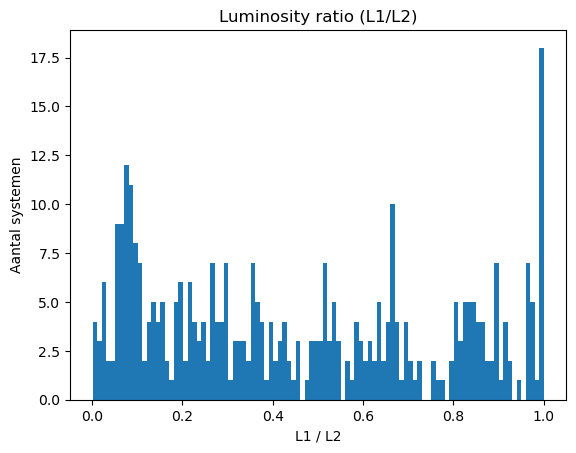

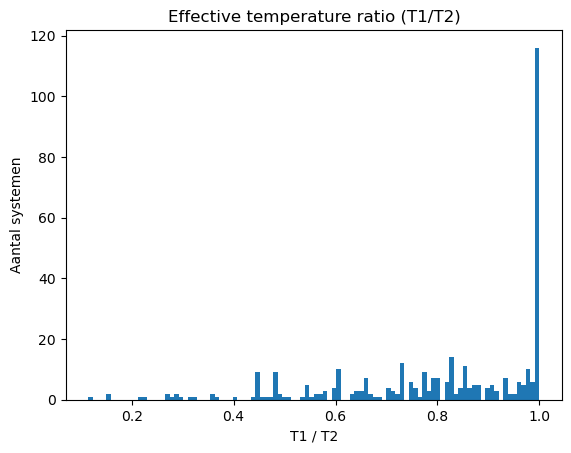

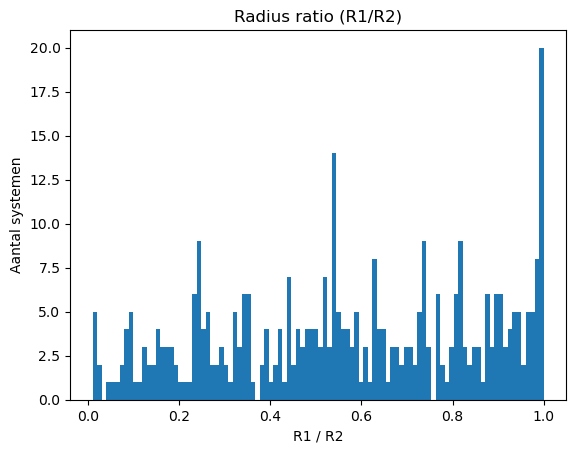


MEAN MASSES

   Stellar Class  Mean Mass (M_sun)
0  Main Sequence               0.45
1   White Dwarfs               0.60
2   Brown Dwarfs               0.04
3         Giants               1.20
4          Other               1.40

BINARY SYSTEM PROBABILITIES

           Star 1         Star 2  Probability
0   Main Sequence  Main Sequence     0.837225
1   Main Sequence   White Dwarfs     0.100650
2   Main Sequence   Brown Dwarfs     0.036600
3   Main Sequence         Giants     0.012810
4   Main Sequence          Other     0.005490
5    White Dwarfs   White Dwarfs     0.003025
6    White Dwarfs   Brown Dwarfs     0.002200
7    White Dwarfs         Giants     0.000770
8    Brown Dwarfs   Brown Dwarfs     0.000400
9    White Dwarfs          Other     0.000330
10   Brown Dwarfs         Giants     0.000280
11   Brown Dwarfs          Other     0.000120
12         Giants         Giants     0.000049
13         Giants          Other     0.000042
14          Other          Other     0.000009

MON

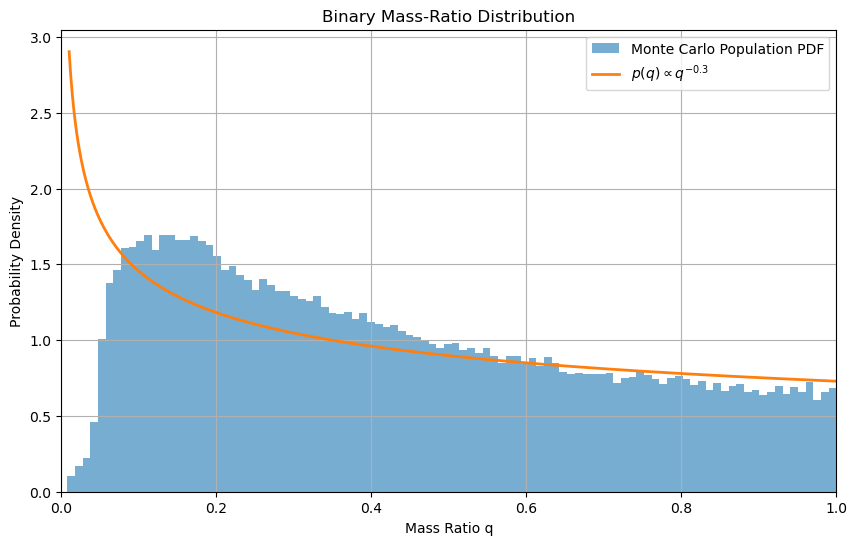

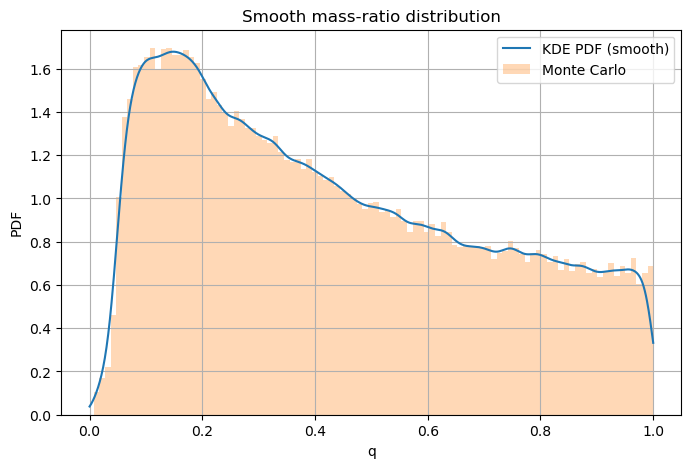

CSV saved: DATA/RAW/q_mass_ratio_distribution.csv


In [56]:
# ============================================================
# df_ratios structuur + histogrammen van systeem-ratio's
# ============================================================

# Structuur van df_ratios (output van system-level analysis):
#
# df_ratios.append({
#     "system_id": system,
#     "L_ratio": L_ratio,
#     "L_ratio_err": L_ratio_err,
#     "T_eff_ratio": T_ratio,
#     "T_eff_ratio_err": T_ratio_err,
#     "R_ratio": R_ratio,
#     "R_ratio_err": R_ratio_err
# })

df_ratios = pd.DataFrame(df_ratios)

# ============================================================
# Histogrammen van ratio's
# ============================================================

# Theoretische steady-state verdeling (genormaliseerd)
data = {
    "Stellar Class": [
        "Main Sequence",
        "White Dwarfs",
        "Brown Dwarfs",
        "Giants",
        "Other"
    ],
    "Fraction": [
        0.915,  # 91.5%
        0.055,  # 5.5%
        0.020,  # 2.0%
        0.007,  # 0.7%
        0.003   # 0.3%
    ]
}

df = pd.DataFrame(data)

print(df)

# ----------------------------
# L ratio
# ----------------------------

plt.figure()
plt.hist(df_ratios["L_ratio"].dropna(), bins=100)
plt.xlabel("L1 / L2")
plt.ylabel("Aantal systemen")
plt.title("Luminosity ratio (L1/L2)")
plt.show()

# ----------------------------
# T_eff ratio
# ----------------------------

plt.figure()
plt.hist(df_ratios["T_eff_ratio"].dropna(), bins=100)
plt.xlabel("T1 / T2")
plt.ylabel("Aantal systemen")
plt.title("Effective temperature ratio (T1/T2)")
plt.show()

# ----------------------------
# Radius ratio
# ----------------------------

plt.figure()
plt.hist(df_ratios["R_ratio"].dropna(), bins=100)
plt.xlabel("R1 / R2")
plt.ylabel("Aantal systemen")
plt.title("Radius ratio (R1/R2)")
plt.show()








# ============================================================
# STELLAR POPULATION FRACTIONS
# ============================================================

classes = {
    "Main Sequence": 0.915,
    "White Dwarfs": 0.055,
    "Brown Dwarfs": 0.020,
    "Giants": 0.007,
    "Other": 0.003
}

# ============================================================
# MEAN MASSES (REFERENCE ONLY)
# ============================================================

mass_data = {
    "Stellar Class": [
        "Main Sequence",
        "White Dwarfs",
        "Brown Dwarfs",
        "Giants",
        "Other"
    ],
    "Mean Mass (M_sun)": [
        0.45,
        0.60,
        0.04,
        1.20,
        1.40
    ]
}

df_mass = pd.DataFrame(mass_data)

print("\n============================================================")
print("MEAN MASSES")
print("============================================================\n")
print(df_mass)

# ============================================================
# BINARY SYSTEM PROBABILITIES
# ============================================================

pairs = list(itertools.combinations_with_replacement(classes.keys(), 2))

results = []

for a, b in pairs:

    pa = classes[a]
    pb = classes[b]

    if a == b:
        prob = pa * pb
    else:
        prob = 2 * pa * pb

    results.append({
        "Star 1": a,
        "Star 2": b,
        "Probability": prob
    })

df_pairs = pd.DataFrame(results)

df_pairs = df_pairs.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

print("\n============================================================")
print("BINARY SYSTEM PROBABILITIES")
print("============================================================\n")
print(df_pairs)

# ============================================================
# MASS DISTRIBUTION SAMPLERS
# ============================================================

def sample_main_sequence():
    """
    Approximate Kroupa-like IMF sampler
    """

    alpha = 1.3

    m_min = 0.08
    m_max = 2.0

    u = np.random.random()

    exponent = 1 - alpha

    mass = (
        (
            u * (m_max**exponent - m_min**exponent)
            + m_min**exponent
        )
    )**(1 / exponent)

    return mass


def sample_white_dwarf():

    mass = np.random.normal(
        loc=0.60,
        scale=0.08
    )

    return np.clip(mass, 0.3, 1.4)


def sample_brown_dwarf():

    return np.random.uniform(
        0.013,
        0.080
    )


def sample_giant():

    mass = np.random.normal(
        loc=1.5,
        scale=0.3
    )

    return np.clip(mass, 0.8, 5.0)


def sample_other():

    mass = np.random.normal(
        loc=1.4,
        scale=0.2
    )

    return np.clip(mass, 1.0, 10.0)

# ============================================================
# GENERAL MASS SAMPLER
# ============================================================

def sample_mass(stellar_class):

    if stellar_class == "Main Sequence":
        return sample_main_sequence()

    elif stellar_class == "White Dwarfs":
        return sample_white_dwarf()

    elif stellar_class == "Brown Dwarfs":
        return sample_brown_dwarf()

    elif stellar_class == "Giants":
        return sample_giant()

    elif stellar_class == "Other":
        return sample_other()

# ============================================================
# MONTE CARLO BINARY POPULATION
# ============================================================

stellar_classes = list(classes.keys())
weights = list(classes.values())

N = 100000

q_values = []

binary_results = []

for _ in range(N):

    # --------------------------------------------------------
    # Choose stellar classes
    # --------------------------------------------------------

    c1 = np.random.choice(
        stellar_classes,
        p=weights
    )

    c2 = np.random.choice(
        stellar_classes,
        p=weights
    )

    # --------------------------------------------------------
    # Sample masses
    # --------------------------------------------------------

    m1 = sample_mass(c1)
    m2 = sample_mass(c2)

    # --------------------------------------------------------
    # Define primary and secondary
    # --------------------------------------------------------

    primary = max(m1, m2)
    secondary = min(m1, m2)

    # --------------------------------------------------------
    # Mass ratio
    # --------------------------------------------------------

    q = secondary / primary

    q_values.append(q)

    binary_results.append({
        "Class 1": c1,
        "Class 2": c2,
        "Mass 1": m1,
        "Mass 2": m2,
        "q": q
    })

# ============================================================
# CREATE DATAFRAME
# ============================================================

df_binaries = pd.DataFrame(binary_results)

print("\n============================================================")
print("MONTE CARLO BINARY SAMPLE")
print("============================================================\n")
print(df_binaries.head())

# ============================================================
# BUILD PDF OF q
# ============================================================

hist, bin_edges = np.histogram(
    q_values,
    bins=100,
    density=True
)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

pdf_q = pd.DataFrame({
    "q": bin_centers,
    "PDF": hist
})

# ============================================================
# THEORETICAL DISTRIBUTION
# ============================================================

q_grid = np.linspace(0.01, 1.0, 1000)

theory_pdf = q_grid**(-0.3)

# Normalize theoretical PDF
theory_pdf /= np.trapz(theory_pdf, q_grid)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

# Monte Carlo PDF
plt.hist(
    q_values,
    bins=100,
    density=True,
    alpha=0.6,
    label="Monte Carlo Population PDF"
)

# Theoretical q^-0.3 PDF
plt.plot(
    q_grid,
    theory_pdf,
    linewidth=2,
    label=r"$p(q)\propto q^{-0.3}$"
)

plt.xlabel("Mass Ratio q")
plt.ylabel("Probability Density")
plt.title("Binary Mass-Ratio Distribution")

plt.xlim(0, 1)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# OPTIONAL: SAVE DATA
# ============================================================

# pdf_q.to_csv("q_pdf.csv", index=False)
# df_binaries.to_csv("binary_population.csv", index=False)







# KDE fit op je samples
kde = gaussian_kde(q_values, bw_method=0.05)

# continue x-as
q_grid = np.linspace(0.0, 1.0, 1000)

# gesmoothte PDF
pdf_smooth = kde(q_grid)

# plot
plt.figure(figsize=(8,5))
plt.plot(q_grid, pdf_smooth, label="KDE PDF (smooth)")
plt.hist(q_values, bins=100, density=True, alpha=0.3, label="Monte Carlo")
plt.xlabel("q")
plt.ylabel("PDF")
plt.legend()
plt.title("Smooth mass-ratio distribution")
plt.grid()
plt.show()







# ============================================================
# BUILD PDF (uit jouw bestaande q_values)
# ============================================================

hist, bin_edges = np.histogram(q_values, bins=100, density=True)
q_grid = 0.5 * (bin_edges[:-1] + bin_edges[1:])

pdf = hist

# ============================================================
# CONSTRUCT CDF
# ============================================================

cdf = np.cumsum(pdf)
cdf /= cdf[-1]   # normalisatie naar 1

# ============================================================
# SAVE TO CSV (SHARED FILE)
# ============================================================

df_export = pd.DataFrame({
    "q": q_grid,
    "PDF": pdf,
    "CDF": cdf
})

df_export.to_csv("DATA/RAW/q_mass_ratio_distribution.csv", index=False)

print("CSV saved: DATA/RAW/q_mass_ratio_distribution.csv")








SYSTEM PARAMETERS

                           System    Weight  Gamma   q_c  Beta
0   Main Sequence - Main Sequence  0.837225   -0.3  0.03   0.3
1    Main Sequence - White Dwarfs  0.100650   -0.5  0.04   0.5
2    Main Sequence - Brown Dwarfs  0.036600   -1.0  0.12   1.0
3          Main Sequence - Giants  0.012810   -0.2  0.05   0.4
4           Main Sequence - Other  0.005490   -0.4  0.06   0.7
5     White Dwarfs - White Dwarfs  0.003025    0.3  0.01  -0.3
6     White Dwarfs - Brown Dwarfs  0.002200   -0.8  0.10   0.8
7           White Dwarfs - Giants  0.000770   -0.2  0.05   0.5
8            White Dwarfs - Other  0.000330    0.2  0.02  -0.1
9     Brown Dwarfs - Brown Dwarfs  0.000400    0.5  0.03  -0.4
10          Brown Dwarfs - Giants  0.000280   -1.0  0.18   1.2
11           Brown Dwarfs - Other  0.000120   -1.2  0.20   1.5
12                Giants - Giants  0.000049    0.4  0.02  -0.2
13                 Giants - Other  0.000042   -0.3  0.07   0.6
14                  Other - Other  

C:\Users\damia\AppData\Local\Temp\ipykernel_21612\222004374.py:140: RuntimeWarning: divide by zero encountered in power
  * (1 - q_grid)**beta


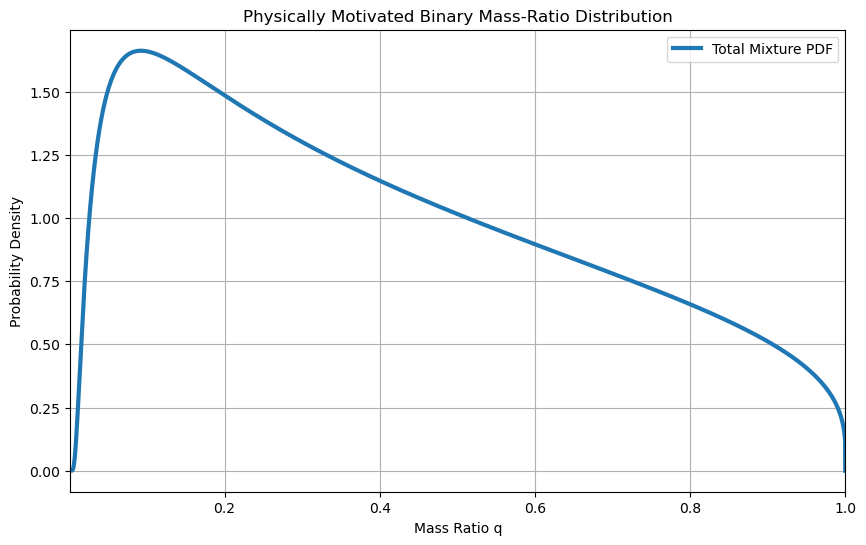

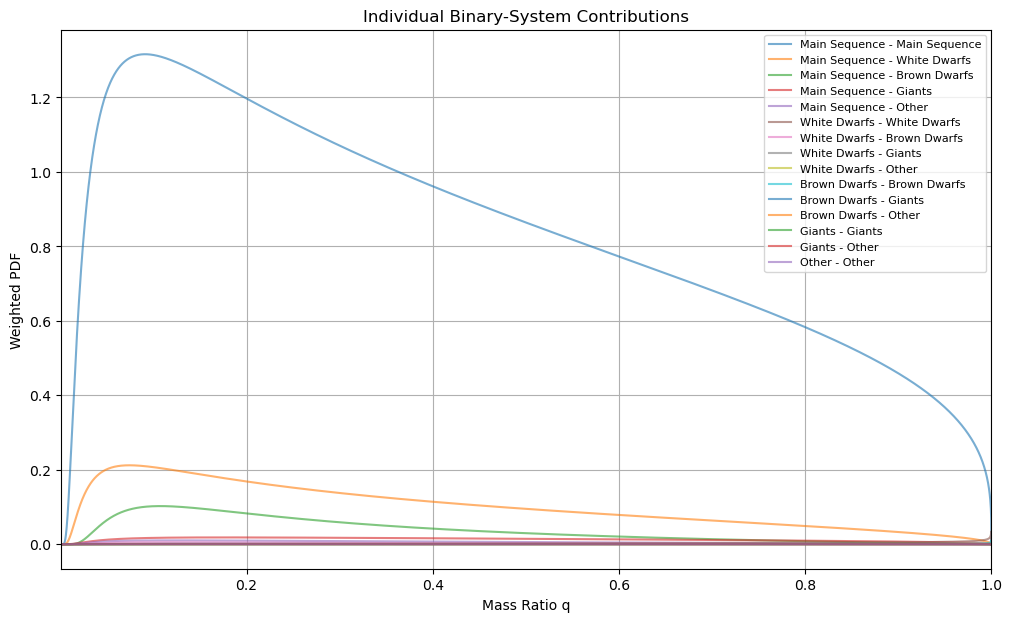

In [57]:
# ============================================================
# STELLAR POPULATION FRACTIONS
# ============================================================

classes = {
    "Main Sequence": 0.915,
    "White Dwarfs": 0.055,
    "Brown Dwarfs": 0.020,
    "Giants": 0.007,
    "Other": 0.003
}

# ============================================================
# SYSTEM-SPECIFIC PARAMETERS
#
# gamma  -> global slope
# q_c    -> low-q suppression scale
# beta   -> high-q suppression
# ============================================================

params_dict = {

    ("Main Sequence", "Main Sequence"):
        {"gamma": -0.3, "q_c": 0.03, "beta": 0.3},

    ("Main Sequence", "White Dwarfs"):
        {"gamma": -0.5, "q_c": 0.04, "beta": 0.5},

    ("Main Sequence", "Brown Dwarfs"):
        {"gamma": -1.0, "q_c": 0.12, "beta": 1.0},

    ("Main Sequence", "Giants"):
        {"gamma": -0.2, "q_c": 0.05, "beta": 0.4},

    ("Main Sequence", "Other"):
        {"gamma": -0.4, "q_c": 0.06, "beta": 0.7},

    ("White Dwarfs", "White Dwarfs"):
        {"gamma": +0.3, "q_c": 0.01, "beta": -0.3},

    ("White Dwarfs", "Brown Dwarfs"):
        {"gamma": -0.8, "q_c": 0.10, "beta": 0.8},

    ("White Dwarfs", "Giants"):
        {"gamma": -0.2, "q_c": 0.05, "beta": 0.5},

    ("White Dwarfs", "Other"):
        {"gamma": +0.2, "q_c": 0.02, "beta": -0.1},

    ("Brown Dwarfs", "Brown Dwarfs"):
        {"gamma": +0.5, "q_c": 0.03, "beta": -0.4},

    ("Brown Dwarfs", "Giants"):
        {"gamma": -1.0, "q_c": 0.18, "beta": 1.2},

    ("Brown Dwarfs", "Other"):
        {"gamma": -1.2, "q_c": 0.20, "beta": 1.5},

    ("Giants", "Giants"):
        {"gamma": +0.4, "q_c": 0.02, "beta": -0.2},

    ("Giants", "Other"):
        {"gamma": -0.3, "q_c": 0.07, "beta": 0.6},

    ("Other", "Other"):
        {"gamma": +0.5, "q_c": 0.01, "beta": -0.4}
}

# ============================================================
# GENERATE SYSTEM WEIGHTS
# ============================================================

pairs = list(itertools.combinations_with_replacement(classes.keys(), 2))

results = []

for a, b in pairs:

    pa = classes[a]
    pb = classes[b]

    # unordered pair probability
    if a == b:
        weight = pa * pb
    else:
        weight = 2 * pa * pb

    params = params_dict[(a, b)]

    results.append({
        "System": f"{a} - {b}",
        "Weight": weight,
        "Gamma": params["gamma"],
        "q_c": params["q_c"],
        "Beta": params["beta"]
    })

df_systems = pd.DataFrame(results)

print("\n===================================================")
print("SYSTEM PARAMETERS")
print("===================================================\n")
print(df_systems)

# ============================================================
# q GRID
# ============================================================

q_min = 0.001
q_max = 1.0

q_grid = np.linspace(q_min, q_max, 5000)

# ============================================================
# BUILD TOTAL PDF
# ============================================================

total_pdf = np.zeros_like(q_grid)

component_pdfs = {}

for _, row in df_systems.iterrows():

    system = row["System"]

    weight = row["Weight"]
    gamma = row["Gamma"]
    q_c = row["q_c"]
    beta = row["Beta"]

    # ========================================================
    # PHYSICALLY MOTIVATED COMPONENT PDF
    #
    # p(q) ~ q^gamma * exp(-q_c/q) * (1-q)^beta
    # ========================================================

    component_pdf = (
        q_grid**gamma
        * np.exp(-q_c / q_grid)
        * (1 - q_grid)**beta
    )

    # --------------------------------------------------------
    # Remove NaNs/infs
    # --------------------------------------------------------

    component_pdf = np.nan_to_num(
        component_pdf,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # --------------------------------------------------------
    # Normalize component
    # --------------------------------------------------------

    normalization = np.trapz(component_pdf, q_grid)

    component_pdf /= normalization

    # --------------------------------------------------------
    # Weight by binary occurrence rate
    # --------------------------------------------------------

    weighted_pdf = weight * component_pdf

    # --------------------------------------------------------
    # Add to total population PDF
    # --------------------------------------------------------

    total_pdf += weighted_pdf

    # Save component
    component_pdfs[system] = weighted_pdf

# ============================================================
# FINAL NORMALIZATION
# ============================================================

total_pdf /= np.trapz(total_pdf, q_grid)

# ============================================================
# CREATE DATAFRAME
# ============================================================

df_pdf = pd.DataFrame({
    "q": q_grid,
    "PDF": total_pdf
})

print("\n===================================================")
print("TOTAL PDF")
print("===================================================\n")
print(df_pdf.head())

# ============================================================
# PLOT TOTAL PDF
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    q_grid,
    total_pdf,
    linewidth=3,
    label="Total Mixture PDF"
)

plt.xlabel("Mass Ratio q")
plt.ylabel("Probability Density")

plt.title("Physically Motivated Binary Mass-Ratio Distribution")

plt.xlim(q_min, 1)

plt.grid(True)
plt.legend()

plt.show()

# ============================================================
# PLOT INDIVIDUAL COMPONENTS
# ============================================================

plt.figure(figsize=(12, 7))

for system, pdf in component_pdfs.items():

    plt.plot(
        q_grid,
        pdf,
        alpha=0.6,
        label=system
    )

plt.xlabel("Mass Ratio q")
plt.ylabel("Weighted PDF")

plt.title("Individual Binary-System Contributions")

plt.xlim(q_min, 1)

plt.grid(True)
plt.legend(fontsize=8)

plt.show()

# ============================================================
# OPTIONAL SAVE
# ============================================================

# df_pdf.to_csv("q_mixture_model_physical.csv", index=False)

           Class        T_mean         T_std
0  Main Sequence   3569.372600   1433.070704
1   White Dwarfs  22750.000000  17250.000000
2   Brown Dwarfs   1425.000000    613.901458
3         Giants   4669.500000   2858.018501
4          Other   3651.373335   1872.243763

MONTE CARLO TEMPERATURE BINARY SAMPLE

         Class 1        Class 2           T1           T2       q_T
0  Main Sequence  Main Sequence  4995.388818  2526.097759  0.505686
1  Main Sequence  Main Sequence  1825.095731  3471.504097  0.525736
2  Main Sequence  Main Sequence  3123.956987  2842.914380  0.910036
3  Main Sequence  Main Sequence  5962.457760  2869.296684  0.481227
4  Main Sequence  Main Sequence  5626.623530  2299.317067  0.408650


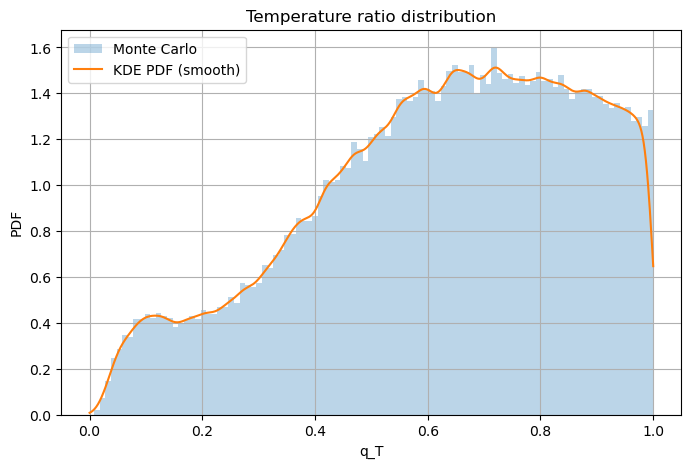

In [60]:
# Hier in deze cell doen we de analyse voor de PDF van q_T

main_seq_spectral_probs = pd.DataFrame({
    "spectral_type": ["O", "B", "A", "F", "G", "K", "M"],
    "probability": [0.0000003, 0.0012, 0.0061, 0.03, 0.076, 0.12, 0.7627]
})

giant_spectral_probs = pd.DataFrame({
    "spectral_type": ["O", "B", "A", "F", "G", "K", "M"],
    "probability": [0.003, 0.005, 0.002, 0.09, 0.20, 0.40, 0.30]
})

wd_spectral_probs = pd.DataFrame({
    "spectral_type": ["D"],
    "probability": [1.0]
})

bd_spectral_probs = pd.DataFrame({
    "spectral_type": ["L", "T"],
    "probability": [0.5, 0.5]
})

other_spectral_probs = pd.DataFrame({
    "spectral_type": ["O", "B", "A", "F", "G", "K", "M", "W", "C", "S"],
    "probability": [0.00000003, 0.0052, 0.0061, 0.03, 0.076, 0.12, 0.7627, 0.0000001, 0.0000001, 0.0000001]
})

class_probability_tables = {
    "Main Sequence": main_seq_spectral_probs,
    "White Dwarfs": wd_spectral_probs,
    "Brown Dwarfs": bd_spectral_probs,
    "Giants": giant_spectral_probs,
    "Other": other_spectral_probs
}

teff_lookup = df_teff.set_index("spectral_type")[["T_gem", "T_std"]]

import numpy as np

def compute_class_teff_stats(prob_df):
    means = []
    variances = []
    weights = []

    for _, row in prob_df.iterrows():
        sptype = row["spectral_type"]
        p = row["probability"]

        if sptype not in teff_lookup.index:
            continue  # safety

        mu = teff_lookup.loc[sptype, "T_gem"]
        sigma = teff_lookup.loc[sptype, "T_std"]

        means.append(mu)
        variances.append(sigma**2)
        weights.append(p)

    weights = np.array(weights)
    means = np.array(means)
    variances = np.array(variances)

    mean_total = np.sum(weights * means)

    var_total = np.sum(weights * (variances + means**2)) - mean_total**2

    return mean_total, np.sqrt(var_total)

stellar_class_probs = {
    "Main Sequence": 0.915,
    "White Dwarfs": 0.055,
    "Brown Dwarfs": 0.020,
    "Giants": 0.007,
    "Other": 0.003
}

results = []

for cls, dfp in class_probability_tables.items():
    mean, std = compute_class_teff_stats(dfp)

    results.append({
        "Class": cls,
        "T_mean": mean,
        "T_std": std
    })

df_class_teff = pd.DataFrame(results)

print(df_class_teff)

# ============================================================
# MONTE CARLO BINARY POPULATION (TEMPERATURE VERSION)
# ============================================================

def sample_teff_lognormal(mu, sigma):
    """
    Log-normal sampling gebaseerd op (mu, sigma) in lineaire ruimte.
    """
    sigma_log = np.sqrt(np.log(1 + (sigma / mu) ** 2))
    mu_log = np.log(mu) - 0.5 * sigma_log**2
    return np.random.lognormal(mu_log, sigma_log)

stellar_classes = list(stellar_class_probs.keys())
weights = list(stellar_class_probs.values())

N = 100000

qT_values = []
binary_T_results = []

for _ in range(N):

    # --------------------------------------------------------
    # Choose stellar classes
    # --------------------------------------------------------
    c1 = np.random.choice(stellar_classes, p=weights)
    c2 = np.random.choice(stellar_classes, p=weights)

    # --------------------------------------------------------
    # Get Teff distributions per class
    # --------------------------------------------------------
    mu1, sigma1 = df_class_teff[df_class_teff["Class"] == c1][["T_mean", "T_std"]].values[0]
    mu2, sigma2 = df_class_teff[df_class_teff["Class"] == c2][["T_mean", "T_std"]].values[0]

    T1 = sample_teff_lognormal(mu1, sigma1)
    T2 = sample_teff_lognormal(mu2, sigma2)

    # --------------------------------------------------------
    # Define primary / secondary (same logic as mass)
    # --------------------------------------------------------
    T_primary = max(T1, T2)
    T_secondary = min(T1, T2)

    qT = T_secondary / T_primary

    # safety clip (numerieke stabiliteit)
    qT = np.clip(qT, 0.0, 1.0)

    qT_values.append(qT)

    binary_T_results.append({
        "Class 1": c1,
        "Class 2": c2,
        "T1": T1,
        "T2": T2,
        "q_T": qT
    })

# ============================================================
# CREATE DATAFRAME
# ============================================================

df_Tbinaries = pd.DataFrame(binary_T_results)

print("\n============================================================")
print("MONTE CARLO TEMPERATURE BINARY SAMPLE")
print("============================================================\n")
print(df_Tbinaries.head())

# ============================================================
# BUILD PDF OF q_T
# ============================================================

hist_T, bin_edges_T = np.histogram(
    qT_values,
    bins=100,
    density=True
)

bin_centers_T = 0.5 * (bin_edges_T[:-1] + bin_edges_T[1:])

pdf_qT = pd.DataFrame({
    "q_T": bin_centers_T,
    "PDF": hist_T
})

from scipy.stats import gaussian_kde

kde_T = gaussian_kde(qT_values, bw_method=0.05)

qT_grid = np.linspace(0.0, 1.0, 1000)
pdf_T_smooth = kde_T(qT_grid)

plt.figure(figsize=(8,5))

plt.hist(qT_values, bins=100, density=True, alpha=0.3, label="Monte Carlo")
plt.plot(qT_grid, pdf_T_smooth, label="KDE PDF (smooth)")

plt.xlabel("q_T")
plt.ylabel("PDF")
plt.title("Temperature ratio distribution")
plt.legend()
plt.grid()
plt.show()

Fraction q_R > 0.9999: 0.18421
Max q_R: 5.990317711853478
Min q_R: 0.029717857417473195


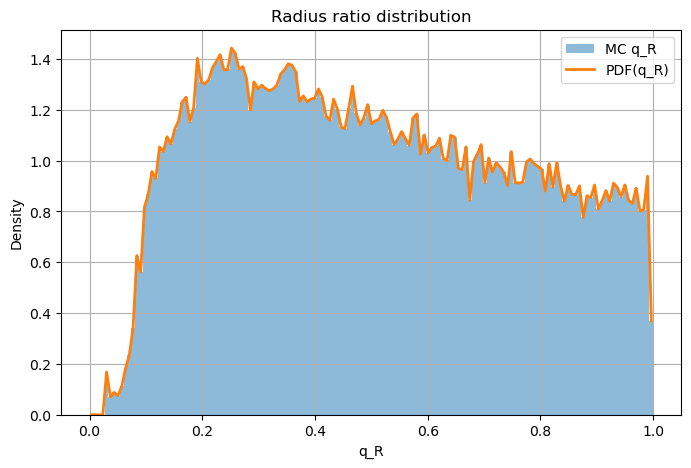

In [61]:
# ============================================================
# q_R Monte Carlo pipeline (FIXED VERSION - stable & physical)
# ============================================================

import numpy as np
import itertools
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# 1. q_m sampling via inverse CDF
# ============================================================

q_vals = pdf_q["q"].values
pdf_vals = pdf_q["PDF"].values

cdf = np.cumsum(pdf_vals)
cdf /= cdf[-1]

inv_cdf = interp1d(
    cdf,
    q_vals,
    bounds_error=False,
    fill_value=(q_vals[0], q_vals[-1])
)

def sample_qm(n):
    u = np.random.rand(n)
    return inv_cdf(u)


# ============================================================
# 2. stellar system probabilities
# ============================================================

stellar_class_probs = {
    "Main Sequence": 0.915,
    "White Dwarfs": 0.055,
    "Brown Dwarfs": 0.020,
    "Giants": 0.007,
    "Other": 0.003
}

systems = []
system_probs = []

for a, pa in stellar_class_probs.items():
    for b, pb in stellar_class_probs.items():

        systems.append((a, b))

        p = pa * pb if a == b else 2 * pa * pb
        system_probs.append(p)

system_probs = np.array(system_probs)
system_probs /= system_probs.sum()


# ============================================================
# 3. alpha map (complete + symmetrized)
# ============================================================

alpha_map = {

    ("Main Sequence", "Main Sequence"): 0.8,
    ("White Dwarfs", "White Dwarfs"): -0.33,
    ("Brown Dwarfs", "Brown Dwarfs"): 0.2,
    ("Giants", "Giants"): 0.4,
    ("Other", "Other"): 0.5,

    ("Main Sequence", "White Dwarfs"): -0.25,
    ("Main Sequence", "Brown Dwarfs"): 0.6,
    ("Main Sequence", "Giants"): 0.5,
    ("Main Sequence", "Other"): 0.55,

    ("White Dwarfs", "Brown Dwarfs"): -0.35,
    ("White Dwarfs", "Giants"): -0.45,
    ("White Dwarfs", "Other"): -0.30,

    ("Brown Dwarfs", "Giants"): 0.35,
    ("Brown Dwarfs", "Other"): 0.4,

    ("Giants", "Other"): 0.45,
}

# symmetrise (critical)
alpha_map = {**alpha_map, **{(b, a): v for (a, b), v in alpha_map.items()}}


# ============================================================
# 4. Monte Carlo
# ============================================================

N = 100000
qR_values = []

eps = 1e-12  # numerical safety only (NOT physics clipping)

for _ in range(N):

    # 1. system
    idx = np.random.choice(len(systems), p=system_probs)
    a, b = systems[idx]

    # 2. sample q_m
    q_m = sample_qm(1)[0]
    q_m = np.clip(q_m, eps, 1 - eps)

    # 3. alpha
    alpha = alpha_map[(a, b)]

    # 4. STABLE TRANSFORM (log-space)
    # q_R = q_m^alpha  => log(q_R) = alpha * log(q_m)
    log_qR = alpha * np.log(q_m)
    q_R = np.exp(log_qR)

    qR_values.append(q_R)


qR_values = np.array(qR_values)


# ============================================================
# 5. PDF construction (stable bins)
# ============================================================

bins = np.linspace(0, 1, 150)

hist_R, bin_edges_R = np.histogram(qR_values, bins=bins, density=True)
bin_centers_R = 0.5 * (bin_edges_R[:-1] + bin_edges_R[1:])

pdf_qR = pd.DataFrame({
    "q_R": bin_centers_R,
    "PDF": hist_R
})


# ============================================================
# 6. diagnostics
# ============================================================

print("Fraction q_R > 0.9999:", np.mean(qR_values > 0.9999))
print("Max q_R:", np.max(qR_values))
print("Min q_R:", np.min(qR_values))


# ============================================================
# 7. plots
# ============================================================

plt.figure(figsize=(8,5))
plt.hist(qR_values, bins=bins, density=True, alpha=0.5, label="MC q_R")
plt.plot(pdf_qR["q_R"], pdf_qR["PDF"], lw=2, label="PDF(q_R)")
plt.xlabel("q_R")
plt.ylabel("Density")
plt.title("Radius ratio distribution")
plt.legend()
plt.grid()
plt.show()



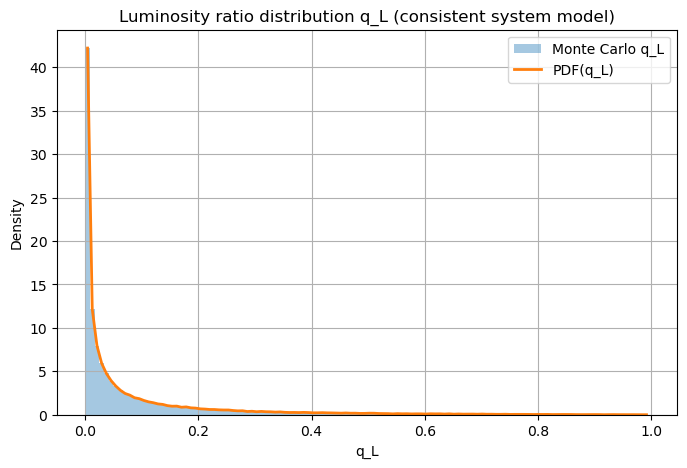

max q_T: 0.29105472798702253
max q_R: 0.8203467249999253
max q_L: 0.9958475648536638
q_L > 1 fraction: 0.0


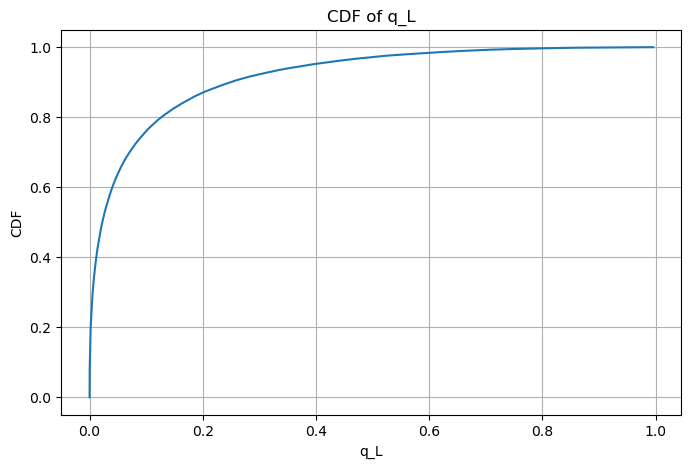

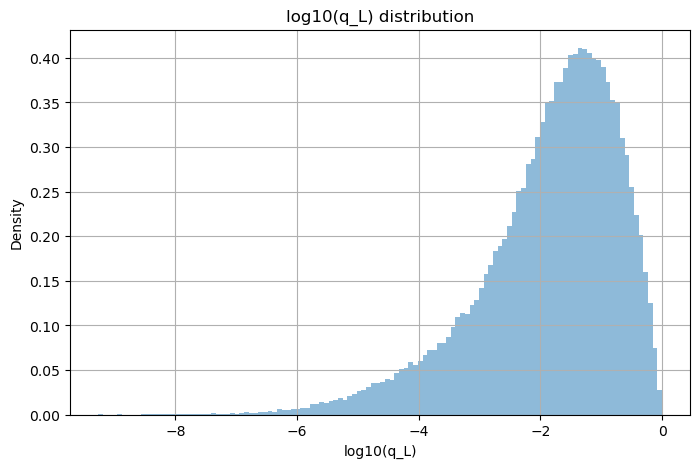

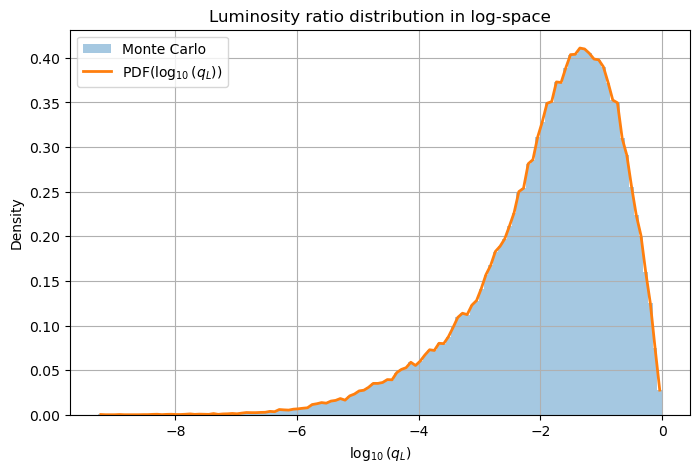

In [62]:
# ============================================================
# FULL SYSTEM-LEVEL MONTE CARLO → q_L distribution
# ============================================================

import numpy as np
import itertools
import matplotlib.pyplot as plt

# ============================================================
# 1. System probabilities P(a,b)
# ============================================================

stellar_class_probs = {
    "Main Sequence": 0.915,
    "White Dwarfs": 0.055,
    "Brown Dwarfs": 0.020,
    "Giants": 0.007,
    "Other": 0.003
}

systems = []
system_probs = []

for a, pa in stellar_class_probs.items():
    for b, pb in stellar_class_probs.items():

        systems.append((a, b))

        p = pa * pb if a == b else 2 * pa * pb
        system_probs.append(p)

system_probs = np.array(system_probs)
system_probs /= system_probs.sum()

# ============================================================
# 2. alpha map (for radius scaling)
# ============================================================

alpha_map = {
    ("Main Sequence", "Main Sequence"): 0.8,
    ("White Dwarfs", "White Dwarfs"): -0.33,
    ("Brown Dwarfs", "Brown Dwarfs"): 0.2,
    ("Giants", "Giants"): 0.4,
    ("Other", "Other"): 0.5,

    ("Main Sequence", "White Dwarfs"): -0.25,
    ("Main Sequence", "Brown Dwarfs"): 0.6,
    ("Main Sequence", "Giants"): 0.5,
    ("Main Sequence", "Other"): 0.55,

    ("White Dwarfs", "Brown Dwarfs"): -0.35,
    ("White Dwarfs", "Giants"): -0.45,
    ("White Dwarfs", "Other"): -0.30,

    ("Brown Dwarfs", "Giants"): 0.35,
    ("Brown Dwarfs", "Other"): 0.4,

    ("Giants", "Other"): 0.45,
}

# symmetrise
alpha_map = {**alpha_map, **{(b, a): v for (a, b), v in alpha_map.items()}}

# ============================================================
# 3. stellar mass sampling (your existing functions assumed)
# ============================================================

def sample_mass(stellar_class):
    return sample_main_sequence() if stellar_class == "Main Sequence" else \
           sample_white_dwarf() if stellar_class == "White Dwarfs" else \
           sample_brown_dwarf() if stellar_class == "Brown Dwarfs" else \
           sample_giant() if stellar_class == "Giants" else \
           sample_other()

# ============================================================
# 4. temperature sampling per class (from your df_class_teff)
# ============================================================

teff_lookup = df_class_teff.set_index("Class")[["T_mean", "T_std"]]

def sample_teff(cls):

    mu, sigma = teff_lookup.loc[cls]

    # convert mean/std to lognormal parameters
    variance = sigma**2

    sigma_log = np.sqrt(np.log(1 + variance / mu**2))
    mu_log = np.log(mu) - 0.5 * sigma_log**2

    T = np.random.lognormal(mu_log, sigma_log)

    # physical clipping
    T = np.clip(T, 100, 300000)

    return T

# ============================================================
# 5. MONTE CARLO
# ============================================================

N = 100000

qL_values = []

for _ in range(N):

    # ----------------------------
    # system
    # ----------------------------
    idx = np.random.choice(len(systems), p=system_probs)
    a, b = systems[idx]

    # ----------------------------
    # masses → q_m
    # ----------------------------
    m1 = sample_mass(a)
    m2 = sample_mass(b)

    m_primary = max(m1, m2)
    m_secondary = min(m1, m2)

    q_m = m_secondary / m_primary

    # ----------------------------
    # temperatures → q_T
    # ----------------------------
    T1 = sample_teff(a)
    T2 = sample_teff(b)

    T_primary = max(T1, T2)
    T_secondary = min(T1, T2)

    q_T = T_secondary / T_primary
    q_T = np.clip(q_T, 1e-8, 1.0)

    # ----------------------------
    # radius ratio
    # ----------------------------
    alpha = alpha_map[(a, b)]
    # radius scaling
    R1 = m1 ** alpha
    R2 = m2 ** alpha

    R_primary = max(R1, R2)
    R_secondary = min(R1, R2)

    q_R = R_secondary / R_primary
    q_R = np.clip(q_R, 1e-8, 1.0)

    # ----------------------------
    # luminosity ratio
    # L ∝ R^2 T^4
    # ----------------------------
    q_L = (q_R ** 2) * (q_T ** 4)

    # safety clamp (numerical)
    q_L = max(q_L, 1e-12)

    qL_values.append(q_L)

# ============================================================
# 6. PDF(q_L)
# ============================================================

hist_L, bin_edges_L = np.histogram(qL_values, bins=120, density=True)
bin_centers_L = 0.5 * (bin_edges_L[:-1] + bin_edges_L[1:])

pdf_qL = pd.DataFrame({
    "q_L": bin_centers_L,
    "PDF": hist_L
})

# ============================================================
# 7. plot
# ============================================================

plt.figure(figsize=(8,5))
plt.hist(qL_values, bins=120, density=True, alpha=0.4, label="Monte Carlo q_L")
plt.plot(pdf_qL["q_L"], pdf_qL["PDF"], lw=2, label="PDF(q_L)")
plt.xlabel("q_L")
plt.ylabel("Density")
plt.title("Luminosity ratio distribution q_L (consistent system model)")
plt.legend()
plt.grid()
plt.show()


print("max q_T:", np.max(q_T))
print("max q_R:", np.max(q_R))
print("max q_L:", np.max(qL_values))
print("q_L > 1 fraction:", np.mean(np.array(qL_values) > 1))

plt.figure(figsize=(8,5))

sorted_qL = np.sort(qL_values)
cdf = np.arange(len(sorted_qL)) / len(sorted_qL)

plt.plot(sorted_qL, cdf)

plt.xlabel("q_L")
plt.ylabel("CDF")
plt.title("CDF of q_L")
plt.grid()
plt.show()

log_qL = np.log10(qL_values)

plt.figure(figsize=(8,5))
plt.hist(log_qL, bins=120, density=True, alpha=0.5)

plt.xlabel("log10(q_L)")
plt.ylabel("Density")
plt.title("log10(q_L) distribution")

plt.grid()
plt.show()




# ============================================================
# PDF of log10(q_L)
# ============================================================

log_qL = np.log10(qL_values)

# histogram
hist_logL, bin_edges_logL = np.histogram(
    log_qL,
    bins=120,
    density=True
)

bin_centers_logL = 0.5 * (
    bin_edges_logL[:-1] + bin_edges_logL[1:]
)

# dataframe
pdf_log_qL = pd.DataFrame({
    "log10_q_L": bin_centers_logL,
    "PDF": hist_logL
})

# ============================================================
# plot
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    log_qL,
    bins=120,
    density=True,
    alpha=0.4,
    label="Monte Carlo"
)

plt.plot(
    pdf_log_qL["log10_q_L"],
    pdf_log_qL["PDF"],
    linewidth=2,
    label=r"PDF($\log_{10}(q_L)$)"
)

plt.xlabel(r"$\log_{10}(q_L)$")
plt.ylabel("Density")

plt.title(r"Luminosity ratio distribution in log-space")

plt.legend()
plt.grid()
plt.show()

Number of systems: 365
Saved figure: MEDIA/bias_temperature_ratio.pdf


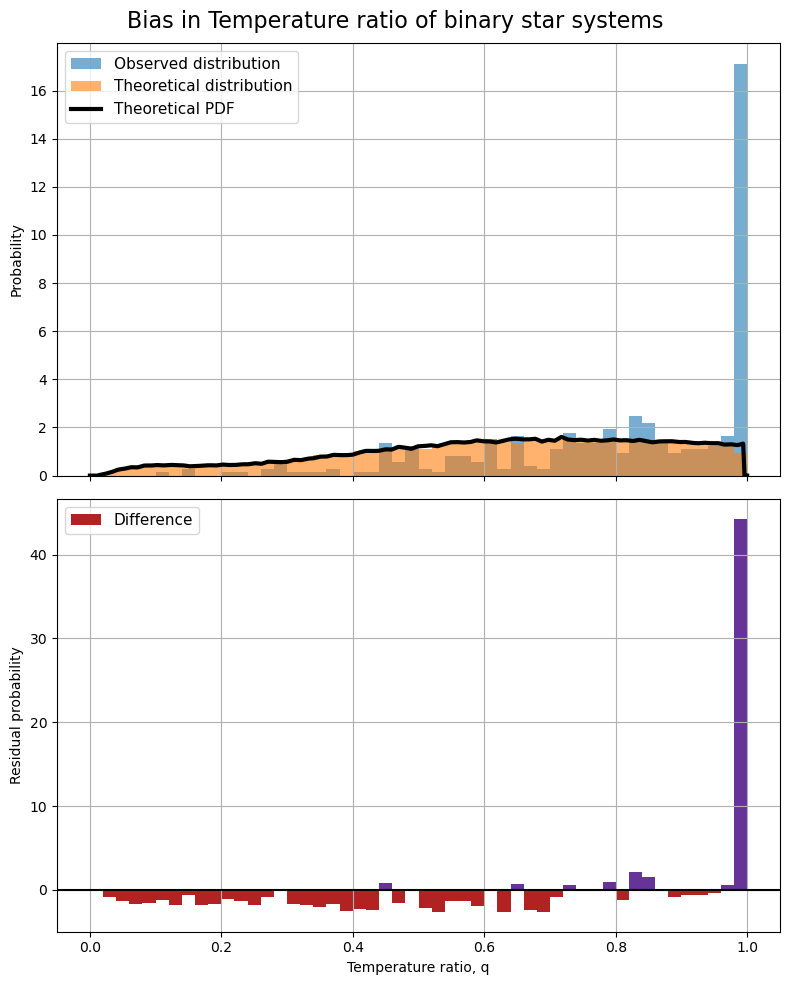

Saved figure: MEDIA/bias_radius_ratio.pdf


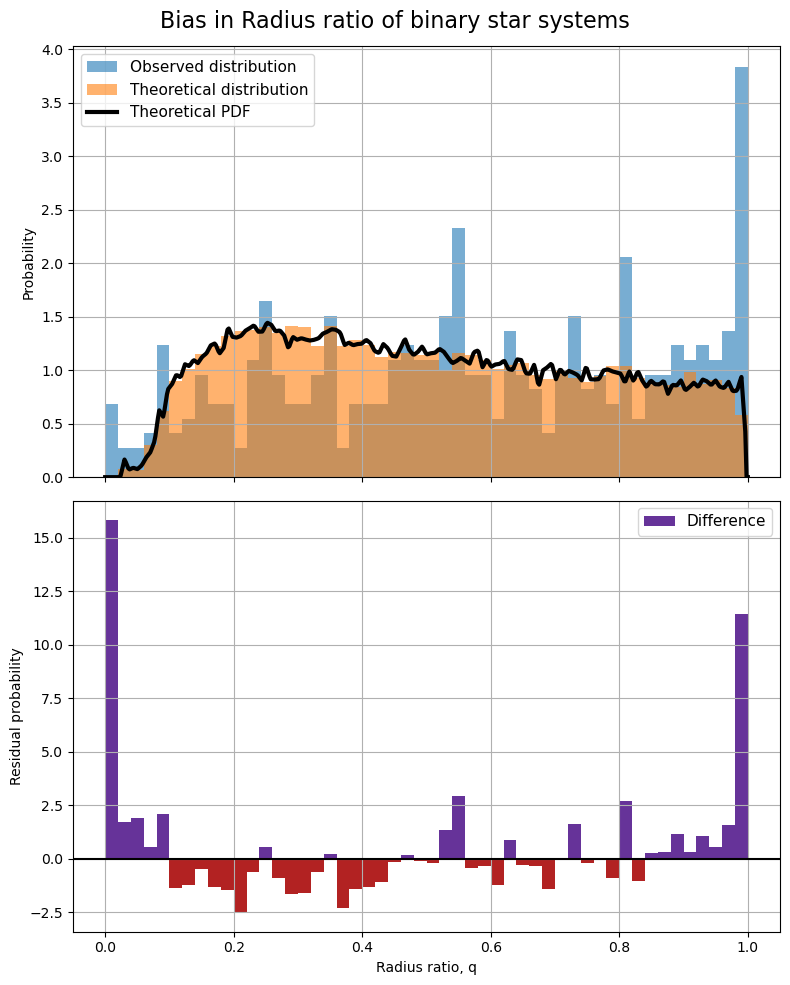

Saved figure: MEDIA/bias_luminosity_ratio.pdf


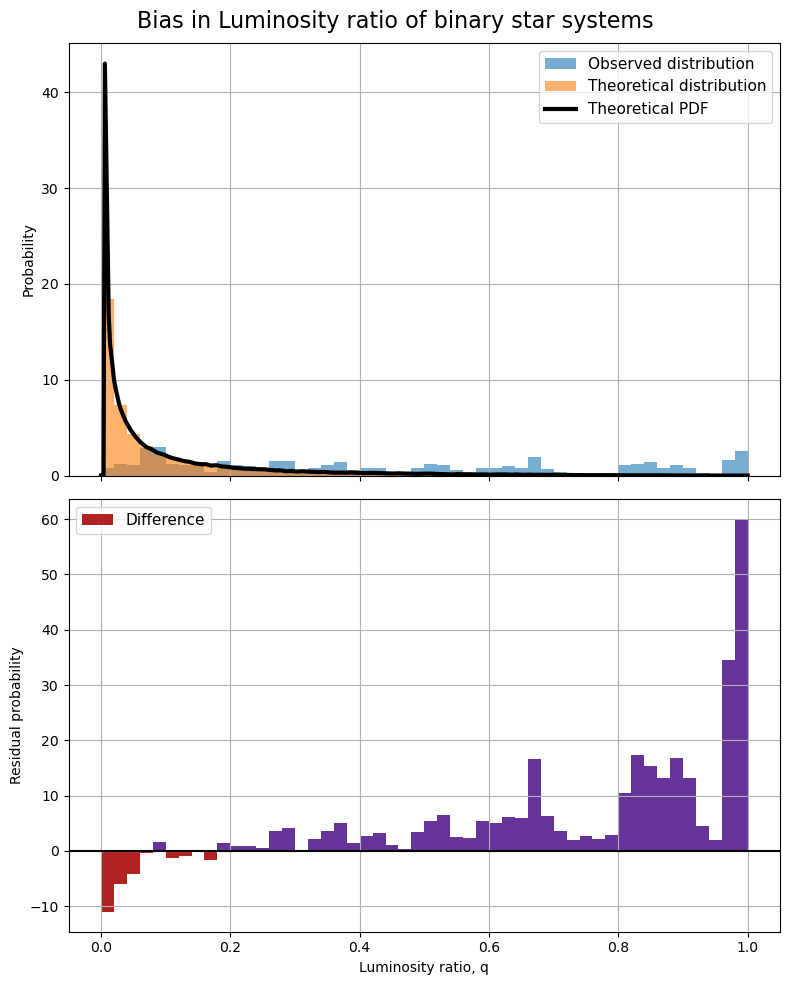

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
import os

# ============================================================
# 1. Smooth inverse CDF sampler (FIXED)
# ============================================================

def build_sampler(pdf_df, xcol, pdfcol="PDF"):

    x = pdf_df[xcol].values
    pdf = pdf_df[pdfcol].values

    pdf = pdf / np.trapz(pdf, x)

    cdf = cumulative_trapezoid(pdf, x, initial=0)
    cdf = cdf / cdf[-1]

    cdf = np.clip(cdf, 0, 1)
    cdf = np.maximum.accumulate(cdf)

    inv_cdf = interp1d(
        cdf,
        x,
        bounds_error=False,
        fill_value=(x[0], x[-1])
    )

    def sampler(n):
        return inv_cdf(np.random.rand(n))

    return sampler


# ============================================================
# 2. Build samplers
# ============================================================

sample_qT = build_sampler(pdf_qT, "q_T")
sample_qR = build_sampler(pdf_qR, "q_R")
sample_qL = build_sampler(pdf_qL, "q_L")


# ============================================================
# 3. DATA
# ============================================================

N_real = len(df_ratios)
print("Number of systems:", N_real)

oversample_factor = 50

theory_qT_big = np.clip(sample_qT(N_real * oversample_factor), 1e-8, 0.999999)
theory_qR_big = np.clip(sample_qR(N_real * oversample_factor), 1e-8, 0.999999)
theory_qL_big = np.clip(sample_qL(N_real * oversample_factor), 1e-12, 0.999999)

obs_qT = np.clip(df_ratios["T_eff_ratio"].dropna().values, 1e-8, 0.999999)
obs_qR = np.clip(df_ratios["R_ratio"].dropna().values, 1e-8, 0.999999)
obs_qL = np.clip(df_ratios["L_ratio"].dropna().values, 1e-12, 0.999999)


# ============================================================
# 4. MAIN PLOTTING FUNCTION (WITH SAVE)
# ============================================================

def plot_q_panel(
    observed,
    theory_samples,
    pdf_df,
    xcol,
    title,
    bins=50,
    pdfcol="PDF"
):

    LABEL_MAP = {
        "q_T": "Temperature",
        "q_R": "Radius",
        "q_L": "Luminosity"
    }

    label = LABEL_MAP.get(xcol, xcol)

    # --------------------------------------------------------
    # BINNING
    # --------------------------------------------------------
    obs_counts, edges = np.histogram(observed, bins=bins, range=(0, 1))
    theory_counts, _ = np.histogram(theory_samples, bins=edges)

    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    # --------------------------------------------------------
    # PROBABILITIES
    # --------------------------------------------------------
    obs_prob = obs_counts / obs_counts.sum()
    theory_prob = theory_counts / theory_counts.sum()

    expected_counts = theory_counts * (obs_counts.sum() / theory_counts.sum())

    sigma = np.sqrt(expected_counts + 1e-1)
    residual = (obs_counts - expected_counts) / sigma

    # --------------------------------------------------------
    # SMOOTH PDF
    # --------------------------------------------------------
    x = pdf_df[xcol].values
    pdf = pdf_df[pdfcol].values

    pdf = pdf / np.trapz(pdf, x)

    x_smooth = np.linspace(0, 1, 500)
    pdf_smooth = interp1d(
        x,
        pdf,
        bounds_error=False,
        fill_value=0.0
    )(x_smooth)

    # --------------------------------------------------------
    # FIGURE
    # --------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(8, 10),
        sharex=True
    )

    # ===================== TOP ==============================
    ax1.hist(
        observed,
        bins=edges,
        density=True,
        alpha=0.6,
        label="Observed distribution"
    )

    ax1.hist(
        theory_samples,
        bins=edges,
        density=True,
        alpha=0.6,
        label="Theoretical distribution"
    )

    ax1.plot(
        x_smooth,
        pdf_smooth,
        color="black",
        lw=3,
        label="Theoretical PDF"
    )

    ax1.set_ylabel("Probability")
    ax1.legend(fontsize=11)
    ax1.grid()

    # ===================== BOTTOM ============================
    colors = np.where(residual > 0, "rebeccapurple", "firebrick")

    ax2.bar(
        centers,
        residual,
        width=widths,
        color=colors,
        align="center",
        label="Difference"
    )

    ax2.axhline(0, color="black")

    ax2.set_xlabel(f"{label} ratio, q")
    ax2.set_ylabel("Residual probability")
    ax2.legend(fontsize=11)
    ax2.grid()

    plt.suptitle(f"Bias in {label} ratio of binary star systems", size=16)
    plt.tight_layout()

    # ========================================================
    # SAVE FIGURE
    # ========================================================
    os.makedirs("MEDIA", exist_ok=True)

    filename = f"MEDIA/bias_{label.lower()}_ratio.pdf"
    plt.savefig(filename, bbox_inches="tight")

    print(f"Saved figure: {filename}")

    plt.show()


# ============================================================
# 5. RUN ALL
# ============================================================

plot_q_panel(obs_qT, theory_qT_big, pdf_qT, "q_T", "q_T")
plot_q_panel(obs_qR, theory_qR_big, pdf_qR, "q_R", "q_R")
plot_q_panel(obs_qL, theory_qL_big, pdf_qL, "q_L", "q_L")